## 1. Импорты и настройки

Эксперименты с моделью **MyModelSynolitic** — k-порядковым приближением условной плотности p(y|x) через формулу обращения Мёбиуса.

> **Ключевое отличие от MyModel**: синолитическая модель — это **прямой классификатор** (обучается на размеченных данных), а не оценщик плотности. Она умеет:
> - `.fit(X, y)` — обучение
> - `.predict(X)` — прямое предсказание класса
> - `.predict_proba(X)` — вероятности классов
> - `.get_feature_matrix(X)` — матрица «сил вершин» для внешнего классификатора


In [80]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [81]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from itertools import combinations
from math import comb
import warnings
warnings.filterwarnings('ignore')

from models_synolitic import MyModelSynolitic
from classification import (
    generate_sphere_dataset,
    get_classifier,
    evaluate_classifier,
    BASELINE_CLASSIFIERS,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

print("Импорт завершён успешно!")
print(f"Baseline классификаторы: {BASELINE_CLASSIFIERS}")


Импорт завершён успешно!
Baseline классификаторы: ['LogisticRegression', 'RandomForest', 'GradientBoosting', 'SVC', 'KNN']


## 2. Демонстрация работы MyModelSynolitic

### 2.1 Коэффициенты Мёбиуса c^(k)(t, d)

Напомним формулу разложения:

$$
\log p(y|\mathbf{x}) \approx_k \sum_{t=0}^{k} c^{(k)}(t, d) \cdot \sum_{T \subset [d]; |T|=t} \log p(y|x_T) + A_{d,k} \cdot \log p(y)
$$

где $c^{(k)}(t, d) = \sum_{s=0}^{k-t} (-1)^s C_{d-t}^{s}$, $A_{d,k} = 1 - \sum_{t=0}^{k} c^{(k)}(t, d) \cdot C_d^t$.

Выведем таблицу коэффициентов для разных k при фиксированном d:


In [82]:
# Коэффициенты Мёбиуса для разных k, при d=10
d_demo = 10
k_max = 4

print(f"Коэффициенты c^(k)(t, d) при d={d_demo}")
print("=" * 70)
header = "k \\ t  " + "  ".join(f"t={t:2d}" for t in range(k_max + 1))
print(header)
print("-" * 70)

for k in range(k_max + 1):
    model_tmp = MyModelSynolitic(d=d_demo, k=k)
    coeffs = [model_tmp._mobius_coeff(t) for t in range(k_max + 1)]
    A = model_tmp._A_coeff()
    row = f"k={k}     " + "  ".join(f"{c:+7.2f}" for c in coeffs)
    row += f"   | A={A:+.4f}"
    print(row)

print()
print("Частные случаи:")
print("  k=0: log p(y|x) ≈ log p(y)   [только приор]")
print("  k=1: эквивалент Naive Bayes")
print("  k=2: синолитика (попарные взаимодействия)")
print("  k=3: тройные взаимодействия (гиперрёбра)")


Коэффициенты c^(k)(t, d) при d=10
k \ t  t= 0  t= 1  t= 2  t= 3  t= 4
----------------------------------------------------------------------
k=0       +1.00    +0.00    +0.00    +0.00    +0.00   | A=+0.0000
k=1       -9.00    +1.00    +0.00    +0.00    +0.00   | A=+0.0000
k=2      +36.00    -8.00    +1.00    +0.00    +0.00   | A=+0.0000
k=3      -84.00   +28.00    -7.00    +1.00    +0.00   | A=+0.0000
k=4     +126.00   -56.00   +21.00    -6.00    +1.00   | A=+0.0000

Частные случаи:
  k=0: log p(y|x) ≈ log p(y)   [только приор]
  k=1: эквивалент Naive Bayes
  k=2: синолитика (попарные взаимодействия)
  k=3: тройные взаимодействия (гиперрёбра)


### 2.2 Число классификаторов в зависимости от k и d

Для каждого порядка t обучается $C_d^t$ классификаторов. Суммарно: $\sum_{t=1}^{k} C_d^t$ классификаторов.


In [83]:
# Таблица количества классификаторов
print("Количество классификаторов: sum_{t=1}^{k} C(d, t)")
print("=" * 60)
header = f"{'k':>3} " + "  ".join(f"d={d:3d}" for d in [5, 8, 10, 15, 20])
print(header)
print("-" * 60)

for k in range(5):
    row = f"k={k}: "
    for d in [5, 8, 10, 15, 20]:
        k_eff = min(k, d)
        total = sum(comb(d, t) for t in range(1, k_eff + 1))
        row += f"  {total:6d}"
    print(row)


Количество классификаторов: sum_{t=1}^{k} C(d, t)
  k d=  5  d=  8  d= 10  d= 15  d= 20
------------------------------------------------------------
k=0:        0       0       0       0       0
k=1:        5       8      10      15      20
k=2:       15      36      55     120     210
k=3:       25      92     175     575    1350
k=4:       30     162     385    1940    6195


### 2.3 Базовая демонстрация: обучение и предсказание на сферах

Покажем, что модель работает для всех частных случаев k=0,1,2,3 на простом датасете.


In [84]:
# Генерируем простой датасет
np.random.seed(42)
d_demo = 8
n_demo = 800

X_demo, y_demo, _ = generate_sphere_dataset(
    n_cases=n_demo // 2,
    n_controls=n_demo // 2,
    n_dims=d_demo,
    model="ideal",
    noise_dims=0,
    random_state=42,
)

X_tr, X_te, y_tr, y_te = train_test_split(X_demo, y_demo, test_size=0.3, random_state=42)

print(f"Данные: X shape={X_demo.shape}, y balance={y_demo.mean():.2%}")
print()
print("Обучение MyModelSynolitic для разных k:")
print("=" * 60)
print(f"{'k':>3} | {'n_classifiers':>14} | {'Accuracy':>10} | {'F1':>8} | {'Коэффициенты'}")
print("-" * 60)

for k in range(min(4, d_demo)):
    m = MyModelSynolitic(d=d_demo, k=k)
    m.fit(X_tr, y_tr)
    y_pred = m.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred, average='binary')
    coeffs = m.get_mobius_coefficients()
    c_str = ", ".join(f"c({t})={v:.2f}" for t, v in enumerate(coeffs['c']))
    print(f"k={k} | {m.n_classifiers_fitted:14d} | {acc:10.4f} | {f1:8.4f} | {c_str}")


Данные: X shape=(800, 8), y balance=50.00%

Обучение MyModelSynolitic для разных k:
  k |  n_classifiers |   Accuracy |       F1 | Коэффициенты
------------------------------------------------------------
k=0 |              0 |     0.4792 |   0.6479 | c(0)=1.00
k=1 |              8 |     0.4750 |   0.4960 | c(0)=-7.00, c(1)=1.00
k=2 |             36 |     0.4417 |   0.4766 | c(0)=21.00, c(1)=-6.00, c(2)=1.00
k=3 |             92 |     0.4583 |   0.4961 | c(0)=-35.00, c(1)=15.00, c(2)=-5.00, c(3)=1.00


## 3. Эксперимент: Классификация на сферах

**Цель:** Сравнить три подхода:
1. **Baseline (Raw X)** — стандартные классификаторы на исходных признаках
2. **Synolitic direct** — `MyModelSynolitic.predict(X)` напрямую
3. **Synolitic features** — `MyModelSynolitic.get_feature_matrix_full_aggregated(X)` + внешний классификатор

### 3.1 Параметры эксперимента


In [85]:
EXPERIMENT_CONFIG = {
    "n_cases": 500,
    "n_controls": 500,
    "n_dims": 10,        # размерность «полезных» признаков
    "noise_dims": 5,     # шумовые признаки (итого d = n_dims + noise_dims = 15)
    "model_type": "ideal",
    "random_state": 42,
    "test_size": 0.3,
    "synolitic_k": 2,    # порядок синолитики
}

D_TOTAL = EXPERIMENT_CONFIG["n_dims"]  # n_dims уже является итоговой размерностью!
print(f"Конфигурация эксперимента:")
for k, v in EXPERIMENT_CONFIG.items():
    print(f"  {k}: {v}")
print(f"  d_total (итоговая размерность): {D_TOTAL}")
print(f"  noise_dims входят в n_dims (n_dims > noise_dims всегда!)")


Конфигурация эксперимента:
  n_cases: 500
  n_controls: 500
  n_dims: 10
  noise_dims: 5
  model_type: ideal
  random_state: 42
  test_size: 0.3
  synolitic_k: 2
  d_total (итоговая размерность): 10
  noise_dims входят в n_dims (n_dims > noise_dims всегда!)


### 3.2 Вспомогательные функции для синолитической модели


In [86]:
def extract_synolitic_features(
    X_train, X_test, y_train,
    d: int, k: int,
    extraction_type: str = "aggregated",  # "sum" | "full" | "aggregated"
    n_jobs: int = -1
):
    """
    Обучает MyModelSynolitic на размеченных данных и извлекает матрицу признаков.

    Типы извлечения:
    - "sum":        s(i,t) = Σ_{T∋i, |T|=t} log p(y=1|x_T)  — «сила вершины»  (n, d*(k+1))
    - "full":       все индивидуальные log p(y=1|x_T)        — (n, Σ C(d,t))
    - "aggregated": описательные статистики по каждой вершине (mean/median/std/min/max)
    """
    model = MyModelSynolitic(d=d, k=k)
    model.fit_parallel(X_train, y_train, n_jobs=n_jobs)

    if extraction_type == "sum":
        X_tr_feat = model.get_feature_matrix(X_train)
        X_te_feat = model.get_feature_matrix(X_test)
    elif extraction_type == "full":
        X_tr_feat, _ = model.get_feature_matrix_full(X_train)
        X_te_feat, _ = model.get_feature_matrix_full(X_test)
    else:  # aggregated
        X_tr_feat, _ = model.get_feature_matrix_full_aggregated(X_train)
        X_te_feat, _ = model.get_feature_matrix_full_aggregated(X_test)

    return X_tr_feat, X_te_feat, model


def evaluate_synolitic_direct(model, X_test, y_test):
    """Оценка прямого предсказания MyModelSynolitic (без внешнего классификатора)."""
    y_pred = model.predict(X_test)
    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred, average="binary"),
        "classifier": "SynoliicDirect",
        "feature_type": "Synolitic Direct",
    }


print("Вспомогательные функции определены.")


Вспомогательные функции определены.


### 3.3 Генерация датасета


In [87]:
X_data, y_data, _ = generate_sphere_dataset(
    n_cases=EXPERIMENT_CONFIG["n_cases"],
    n_controls=EXPERIMENT_CONFIG["n_controls"],
    n_dims=EXPERIMENT_CONFIG["n_dims"],
    model=EXPERIMENT_CONFIG["model_type"],
    noise_dims=EXPERIMENT_CONFIG["noise_dims"],
    random_state=EXPERIMENT_CONFIG["random_state"],
)

X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
    X_data, y_data,
    test_size=EXPERIMENT_CONFIG["test_size"],
    random_state=EXPERIMENT_CONFIG["random_state"],
    stratify=y_data,
)

print(f"Итого признаков: {X_data.shape[1]}  (n_dims={EXPERIMENT_CONFIG['n_dims']} + noise_dims={EXPERIMENT_CONFIG['noise_dims']})")
print(f"Train: {X_train_exp.shape}, Test: {X_test_exp.shape}")
print(f"Баланс классов (train): {y_train_exp.mean():.2%}")


Итого признаков: 10  (n_dims=10 + noise_dims=5)
Train: (700, 10), Test: (300, 10)
Баланс классов (train): 50.00%


### 3.4 Baseline классификаторы на исходных признаках (Raw X)


In [88]:
baseline_results = []
print("Baseline классификаторы на исходных признаках (Raw X):")
print("=" * 65)

for clf_name in BASELINE_CLASSIFIERS:
    clf = get_classifier(clf_name, random_state=EXPERIMENT_CONFIG["random_state"])
    result = evaluate_classifier(
        clf, X_train_exp, X_test_exp, y_train_exp, y_test_exp,
        clf_name=clf_name,
        feature_type="Raw X"
    )
    baseline_results.append(result)
    print(f"  {clf_name:25s} | Accuracy: {result['accuracy']:.4f} | F1: {result['f1_score']:.4f}")


Baseline классификаторы на исходных признаках (Raw X):
  LogisticRegression        | Accuracy: 0.5200 | F1: 0.5200
  RandomForest              | Accuracy: 0.9467 | F1: 0.9484
  GradientBoosting          | Accuracy: 0.9633 | F1: 0.9622
  SVC                       | Accuracy: 0.9967 | F1: 0.9967
  KNN                       | Accuracy: 0.6367 | F1: 0.4293


### 3.5 MyModelSynolitic: прямое предсказание

Модель обучается на `(X_train, y_train)` и сразу выдаёт метки классов.


In [89]:
print("MyModelSynolitic — прямое предсказание (без внешнего классификатора):")
print("=" * 65)

direct_results = []
for k in range(min(4, D_TOTAL)):
    m = MyModelSynolitic(d=D_TOTAL, k=k)
    m.fit_parallel(X_train_exp, y_train_exp, n_jobs=-1)
    res = evaluate_synolitic_direct(m, X_test_exp, y_test_exp)
    res["k"] = k
    res["n_classifiers"] = m.n_classifiers_fitted
    direct_results.append(res)
    print(f"  k={k} (n_clf={m.n_classifiers_fitted:4d}) | Accuracy: {res['accuracy']:.4f} | F1: {res['f1_score']:.4f}")


MyModelSynolitic — прямое предсказание (без внешнего классификатора):
  k=0 (n_clf=   0) | Accuracy: 0.5000 | F1: 0.0000
  k=1 (n_clf=  10) | Accuracy: 0.5267 | F1: 0.5235
  k=2 (n_clf=  55) | Accuracy: 0.5267 | F1: 0.5298
  k=3 (n_clf= 175) | Accuracy: 0.5233 | F1: 0.5217


### 3.6 MyModelSynolitic: признаки + внешний классификатор

Извлекаем матрицу признаков `get_feature_matrix_full_aggregated` и обучаем стандартные классификаторы.


In [90]:
k_feat = EXPERIMENT_CONFIG["synolitic_k"]
extraction_type = "aggregated"

print(f"Извлечение признаков MyModelSynolitic (k={k_feat}, extraction='{extraction_type}')...")
X_tr_syn, X_te_syn, syn_model = extract_synolitic_features(
    X_train_exp, X_test_exp, y_train_exp,
    d=D_TOTAL, k=k_feat,
    extraction_type=extraction_type,
    n_jobs=-1
)
print(f"  Исходные признаки: {X_train_exp.shape[1]}")
print(f"  Synolitic признаки: {X_tr_syn.shape[1]}")
print()

feature_results = []
print(f"Классификаторы на признаках Synolitic (k={k_feat}):")
print("=" * 65)

for clf_name in BASELINE_CLASSIFIERS:
    clf = get_classifier(clf_name, random_state=EXPERIMENT_CONFIG["random_state"])
    result = evaluate_classifier(
        clf, X_tr_syn, X_te_syn, y_train_exp, y_test_exp,
        clf_name=clf_name,
        feature_type=f"Synolitic k={k_feat}"
    )
    feature_results.append(result)
    print(f"  {clf_name:25s} | Accuracy: {result['accuracy']:.4f} | F1: {result['f1_score']:.4f}")


Извлечение признаков MyModelSynolitic (k=2, extraction='aggregated')...
  Исходные признаки: 10
  Synolitic признаки: 111

Классификаторы на признаках Synolitic (k=2):
  LogisticRegression        | Accuracy: 0.9467 | F1: 0.9452
  RandomForest              | Accuracy: 0.9533 | F1: 0.9530
  GradientBoosting          | Accuracy: 0.9633 | F1: 0.9619
  SVC                       | Accuracy: 0.9933 | F1: 0.9933
  KNN                       | Accuracy: 0.8067 | F1: 0.7603


### 3.7 Сравнительный график: Raw X vs Synolitic Direct vs Synolitic Features


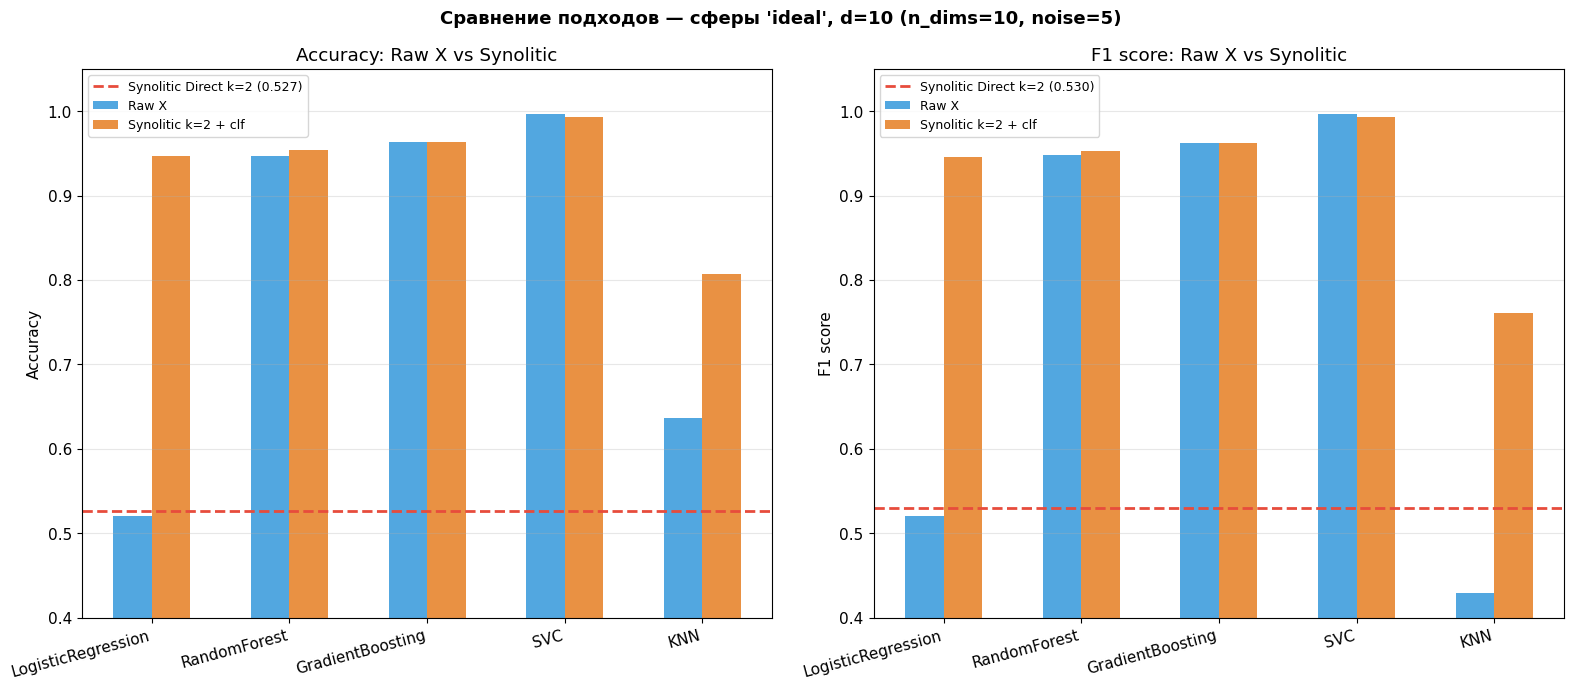

График сохранён.


In [91]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

clf_names = BASELINE_CLASSIFIERS
x = np.arange(len(clf_names))
width = 0.28

k_feat = EXPERIMENT_CONFIG["synolitic_k"]

for ax_idx, metric in enumerate(["accuracy", "f1_score"]):
    ax = axes[ax_idx]

    raw_vals     = [r[metric] for r in baseline_results]
    syn_k_best   = max(direct_results, key=lambda r: r[metric])  # лучший k для прямого
    # Для fair comparison: берём direct k=2 (synolitic)
    k2_direct    = next((r for r in direct_results if r["k"] == 2), direct_results[-1])
    direct_vals  = [k2_direct[metric]] * len(clf_names)  # одно значение, горизонтальная линия
    feat_vals    = [r[metric] for r in feature_results]

    bars1 = ax.bar(x - width, raw_vals,    width, label="Raw X",              color="#3498db", alpha=0.85)
    bars2 = ax.bar(x,          feat_vals,  width, label=f"Synolitic k={k_feat} + clf", color="#e67e22", alpha=0.85)

    # Горизонтальная линия — прямое предсказание синолитики k=2
    ax.axhline(k2_direct[metric], color="#e74c3c", lw=2, ls="--",
               label=f"Synolitic Direct k=2 ({k2_direct[metric]:.3f})")

    ax.set_xticks(x - width/2)
    ax.set_xticklabels(clf_names, rotation=15, ha="right")
    ax.set_ylabel(metric.replace("_", " ").capitalize())
    ax.set_title(f"{metric.replace('_', ' ').capitalize()}: Raw X vs Synolitic")
    ax.legend(fontsize=9)
    ax.set_ylim(0.4, 1.05)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle(f"Сравнение подходов — сферы '{EXPERIMENT_CONFIG['model_type']}', "
             f"d={D_TOTAL} (n_dims={EXPERIMENT_CONFIG['n_dims']}, noise={EXPERIMENT_CONFIG['noise_dims']})",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("images/synolitic_raw_vs_features_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
print("График сохранён.")


### 3.8 Сводная таблица результатов


In [92]:
all_results_3 = (
    [{"Подход": "Raw X", "Классификатор": r["classifier"],
      "Accuracy": r["accuracy"], "F1": r["f1_score"]} for r in baseline_results]
  + [{"Подход": f"Synolitic Direct k={r['k']}", "Классификатор": "—",
      "Accuracy": r["accuracy"], "F1": r["f1_score"]} for r in direct_results]
  + [{"Подход": f"Synolitic k={k_feat} + clf", "Классификатор": r["classifier"],
      "Accuracy": r["accuracy"], "F1": r["f1_score"]} for r in feature_results]
)

df3 = pd.DataFrame(all_results_3)
print("Сводная таблица результатов (модель 'ideal', d={}, noise_dims={})".format(
    EXPERIMENT_CONFIG["n_dims"], EXPERIMENT_CONFIG["noise_dims"]))
print("=" * 70)
print(df3.sort_values("Accuracy", ascending=False).to_string(index=False))


Сводная таблица результатов (модель 'ideal', d=10, noise_dims=5)
              Подход      Классификатор  Accuracy       F1
               Raw X                SVC  0.996667 0.996656
 Synolitic k=2 + clf                SVC  0.993333 0.993289
               Raw X   GradientBoosting  0.963333 0.962199
 Synolitic k=2 + clf   GradientBoosting  0.963333 0.961938
 Synolitic k=2 + clf       RandomForest  0.953333 0.953020
               Raw X       RandomForest  0.946667 0.948387
 Synolitic k=2 + clf LogisticRegression  0.946667 0.945205
 Synolitic k=2 + clf                KNN  0.806667 0.760331
               Raw X                KNN  0.636667 0.429319
Synolitic Direct k=1                  —  0.526667 0.523490
Synolitic Direct k=2                  —  0.526667 0.529801
Synolitic Direct k=3                  —  0.523333 0.521739
               Raw X LogisticRegression  0.520000 0.520000
Synolitic Direct k=0                  —  0.500000 0.000000


## 3.9 Эксперимент: Влияние внутреннего классификатора на качество синолитики

**Идея:** `MyModelSynolitic` использует один и тот же базовый классификатор для моделирования $p(y|x_T)$ по каждому подмножеству $T$. По умолчанию — `LogisticRegression`. Но что если использовать другой?

**Настройка:**
- Фиксируем k=2, d=10 (итоговая размерность)
- Сравниваем внутренние классификаторы: LogisticRegression, GaussianNB, QDA, SVC(rbf), DecisionTree, RandomForest, GradientBoosting
- Все типы сфер: ideal, noisy, broken, hemisphere, noisy_hemisphere
- Метрика: Accuracy и F1-score (прямое предсказание `model.predict`)

**Что ожидаем:**
- GaussianNB / QDA — хорошо для данных с гауссовой структурой
- SVC(rbf) — нелинейная граница, но log-вероятности калиброваны через Platt scaling
- LogisticRegression — линейная граница решений для каждого подмножества
- DecisionTree / RandomForest / GradientBoosting — деревья дают «ступенчатые» log-вероятности, которые могут разрушить агрегацию Мёбиуса


In [93]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# Внутренние классификаторы для сравнения
# Важно: классификатор должен иметь метод predict_log_proba()
INTERNAL_CLASSIFIERS = {
    "LogisticReg":       (LogisticRegression,          {"max_iter": 1000}),
    "GaussianNB":        (GaussianNB,                   {}),
    "QDA":               (QDA,                           {}),
    "SVC(rbf)":          (SVC,                          {"probability": True, "kernel": "rbf"}),
    "DecisionTree":      (DecisionTreeClassifier,       {"max_depth": 5, "random_state": 42}),
    "RandomForest":      (RandomForestClassifier,       {"n_estimators": 50, "max_depth": 5, "random_state": 42}),
    "GradientBoosting":  (GradientBoostingClassifier,   {"n_estimators": 50, "max_depth": 3, "random_state": 42}),
}

# Параметры эксперимента
clf_exp_k     = 2
clf_exp_d     = 10     # итоговая размерность (n_dims в generate_sphere_dataset)
clf_exp_n     = 500
clf_sphere_types = ["ideal", "noisy", "broken", "hemisphere", "noisy_hemisphere"]
clf_exp_seed  = 42

# Результаты: {sphere_type: {clf_name: {"accuracy": ..., "f1": ...}}}
clf_exp_results = {st: {} for st in clf_sphere_types}

print(f"Эксперимент: влияние внутреннего классификатора, k={clf_exp_k}, d={clf_exp_d}")
print("=" * 75)

for sphere_type in clf_sphere_types:
    print(f"\n  Тип: {sphere_type}")
    X_clf, y_clf, _ = generate_sphere_dataset(
        n_cases=clf_exp_n,
        n_controls=clf_exp_n,
        n_dims=clf_exp_d,
        model=sphere_type,
        noise_dims=0,
        random_state=clf_exp_seed,
    )
    X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
        X_clf, y_clf, test_size=0.3, random_state=clf_exp_seed, stratify=y_clf
    )

    for clf_name, (clf_class, clf_params) in INTERNAL_CLASSIFIERS.items():
        try:
            m = MyModelSynolitic(d=clf_exp_d, k=clf_exp_k,
                                 classifier_class=clf_class,
                                 clf_class_params=clf_params)
            m.fit_parallel(X_tr_c, y_tr_c, n_jobs=-1)
            y_pred = m.predict(X_te_c)
            acc = accuracy_score(y_te_c, y_pred)
            f1  = f1_score(y_te_c, y_pred, average="binary")
            clf_exp_results[sphere_type][clf_name] = {"accuracy": acc, "f1": f1}
            print(f"    {clf_name:20s} | Accuracy={acc:.4f} | F1={f1:.4f}")
        except Exception as e:
            clf_exp_results[sphere_type][clf_name] = {"accuracy": float("nan"), "f1": float("nan")}
            print(f"    {clf_name:20s} | ОШИБКА: {e}")

Эксперимент: влияние внутреннего классификатора, k=2, d=10

  Тип: ideal
    LogisticReg          | Accuracy=0.5267 | F1=0.5298
    GaussianNB           | Accuracy=0.9967 | F1=0.9967
    QDA                  | Accuracy=0.9967 | F1=0.9967
    SVC(rbf)             | Accuracy=0.9567 | F1=0.9571
    DecisionTree         | Accuracy=0.3167 | F1=0.0097
    RandomForest         | Accuracy=0.2733 | F1=0.0091
    GradientBoosting     | Accuracy=0.4633 | F1=0.2146

  Тип: noisy
    LogisticReg          | Accuracy=0.5267 | F1=0.5298
    GaussianNB           | Accuracy=0.9967 | F1=0.9967
    QDA                  | Accuracy=0.9967 | F1=0.9967
    SVC(rbf)             | Accuracy=0.9633 | F1=0.9637
    DecisionTree         | Accuracy=0.3167 | F1=0.0097
    RandomForest         | Accuracy=0.2733 | F1=0.0091
    GradientBoosting     | Accuracy=0.4633 | F1=0.2146

  Тип: broken
    LogisticReg          | Accuracy=0.5300 | F1=0.5155
    GaussianNB           | Accuracy=0.9133 | F1=0.9091
    QDA           

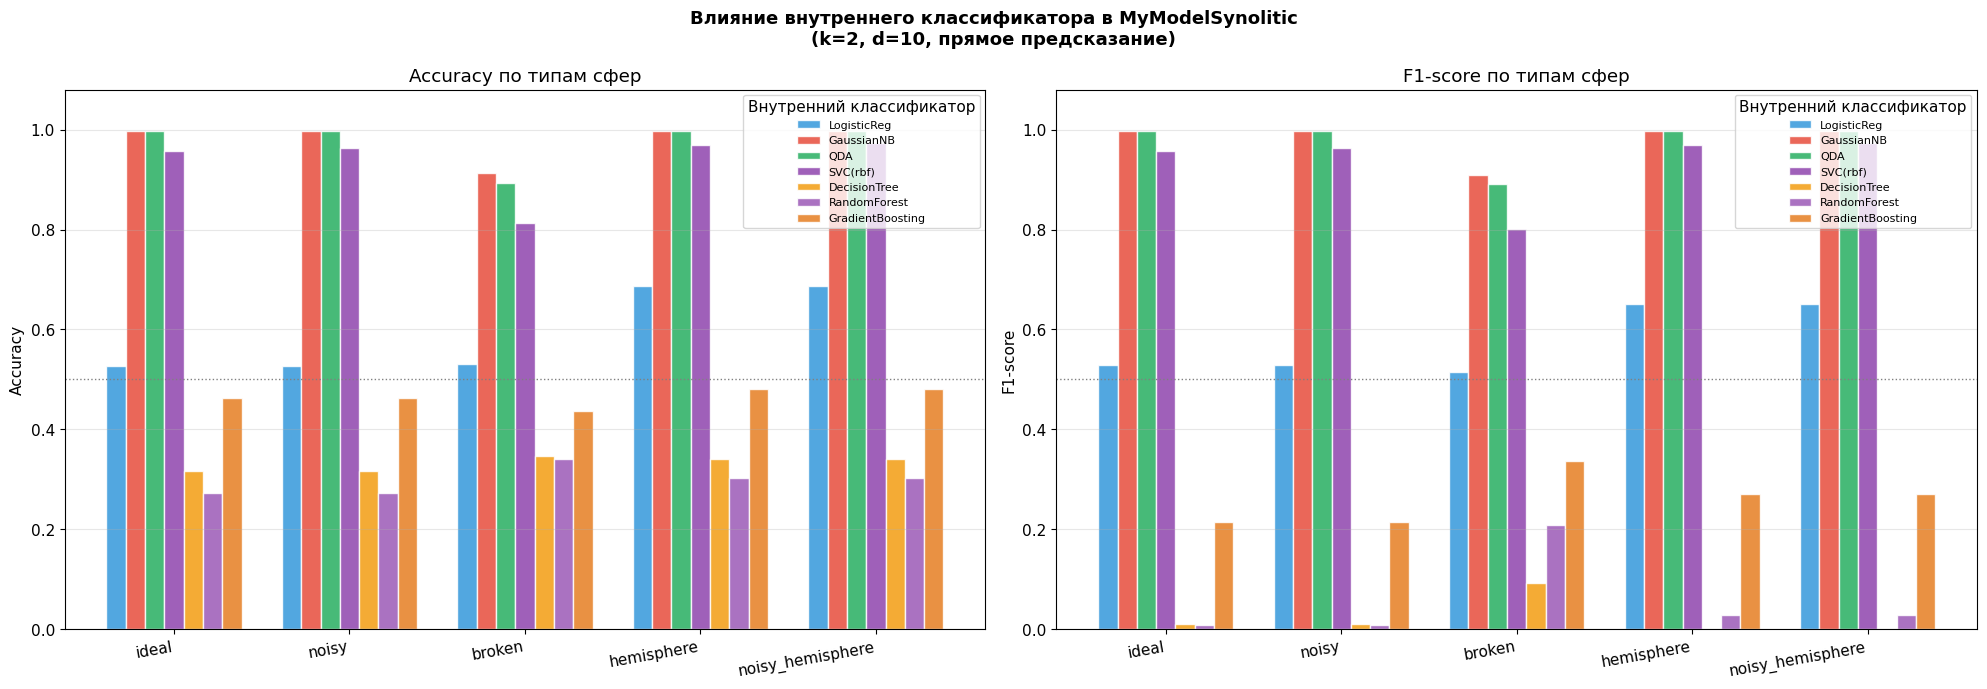

График сохранён.


In [94]:
# ─── Визуализация: grouped bar chart ────────────────────────────────────────
clf_names_list  = list(INTERNAL_CLASSIFIERS.keys())
n_clfs          = len(clf_names_list)
x_pos           = np.arange(len(clf_sphere_types))
width           = 0.11
colors_clf      = ["#3498db", "#e74c3c", "#27ae60", "#8e44ad", "#f39c12", "#9b59b6", "#e67e22"]

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

for ax_idx, metric in enumerate(["accuracy", "f1"]):
    ax = axes[ax_idx]
    for ci, (clf_name, color) in enumerate(zip(clf_names_list, colors_clf)):
        vals = [clf_exp_results[st][clf_name][metric] for st in clf_sphere_types]
        offset = (ci - n_clfs / 2 + 0.5) * width
        ax.bar(x_pos + offset, vals, width,
               label=clf_name, color=color, alpha=0.85, edgecolor="white")

    ax.set_xticks(x_pos)
    ax.set_xticklabels(clf_sphere_types, rotation=10, ha="right")
    ax.set_ylabel(metric.replace("f1", "F1-score").replace("accuracy", "Accuracy"))
    ax.set_title(f"{'Accuracy' if metric=='accuracy' else 'F1-score'} по типам сфер")
    ax.legend(title="Внутренний классификатор", fontsize=8, loc="upper right")
    ax.set_ylim(0.0, 1.08)
    ax.axhline(0.5, color="gray", lw=1, ls=":")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle(
    f"Влияние внутреннего классификатора в MyModelSynolitic\n"
    f"(k={clf_exp_k}, d={clf_exp_d}, прямое предсказание)",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("images/synolitic_internal_clf_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
print("График сохранён.")

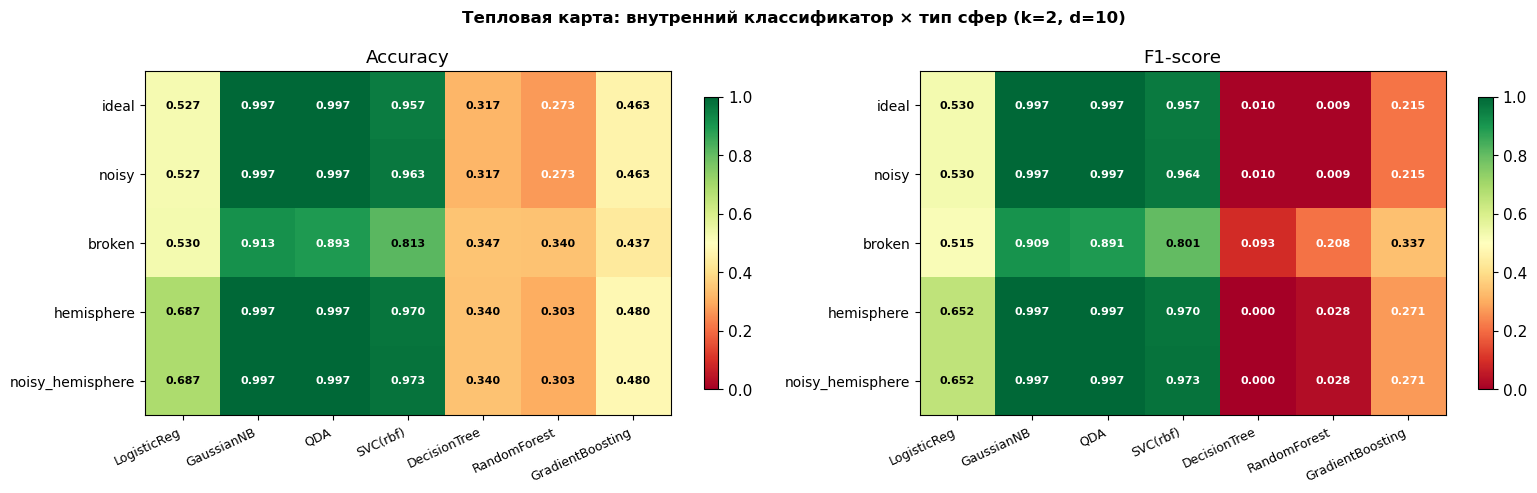

График сохранён.


In [95]:
# ─── Тепловая карта: Accuracy по (тип сферы) × (внутренний классификатор) ───
matrix_acc = np.array([
    [clf_exp_results[st][cn]["accuracy"] for cn in clf_names_list]
    for st in clf_sphere_types
])
matrix_f1 = np.array([
    [clf_exp_results[st][cn]["f1"] for cn in clf_names_list]
    for st in clf_sphere_types
])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, matrix, title in zip(axes,
                              [matrix_acc, matrix_f1],
                              ["Accuracy", "F1-score"]):
    im = ax.imshow(matrix, cmap="RdYlGn", vmin=0.0, vmax=1.0, aspect="auto")
    ax.set_xticks(range(n_clfs))
    ax.set_xticklabels(clf_names_list, rotation=25, ha="right", fontsize=9)
    ax.set_yticks(range(len(clf_sphere_types)))
    ax.set_yticklabels(clf_sphere_types, fontsize=10)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.85)
    # Значения в ячейках
    for r in range(len(clf_sphere_types)):
        for c in range(n_clfs):
            val = matrix[r, c]
            color = "black" if 0.3 < val < 0.85 else "white"
            ax.text(c, r, f"{val:.3f}", ha="center", va="center",
                    fontsize=8, color=color, fontweight="bold")

plt.suptitle(f"Тепловая карта: внутренний классификатор × тип сфер (k={clf_exp_k}, d={clf_exp_d})",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("images/synolitic_internal_clf_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()
print("График сохранён.")

In [96]:
# ─── Дополнительно: как k влияет на выбор лучшего внутреннего классификатора ─
# Фиксируем тип сфер "ideal", сравниваем k=1,2,3 × внутренний классификатор

k_clf_sphere = "ideal"
k_clf_values = [1, 2, 3]

# {k: {clf_name: accuracy}}
k_clf_results = {k: {} for k in k_clf_values}

print(f"Влияние k × внутренний классификатор (тип: {k_clf_sphere}, d={clf_exp_d})")
print("=" * 70)

X_kc, y_kc, _ = generate_sphere_dataset(
    n_cases=clf_exp_n, n_controls=clf_exp_n,
    n_dims=clf_exp_d, model=k_clf_sphere,
    noise_dims=0, random_state=clf_exp_seed,
)
X_tr_kc, X_te_kc, y_tr_kc, y_te_kc = train_test_split(
    X_kc, y_kc, test_size=0.3, random_state=clf_exp_seed, stratify=y_kc
)

for k in k_clf_values:
    print(f"\n  k={k}:")
    for clf_name, (clf_class, clf_params) in INTERNAL_CLASSIFIERS.items():
        try:
            m = MyModelSynolitic(d=clf_exp_d, k=k,
                                 classifier_class=clf_class,
                                 clf_class_params=clf_params)
            m.fit_parallel(X_tr_kc, y_tr_kc, n_jobs=-1)
            y_pred = m.predict(X_te_kc)
            acc = accuracy_score(y_te_kc, y_pred)
            k_clf_results[k][clf_name] = acc
            print(f"    {clf_name:15s} | Accuracy={acc:.4f}")
        except Exception as e:
            k_clf_results[k][clf_name] = float("nan")
            print(f"    {clf_name:15s} | ОШИБКА: {e}")


Влияние k × внутренний классификатор (тип: ideal, d=10)

  k=1:
    LogisticReg     | Accuracy=0.5267
    GaussianNB      | Accuracy=0.9967
    QDA             | Accuracy=0.9967
    SVC(rbf)        | Accuracy=0.9733
    DecisionTree    | Accuracy=0.8133
    RandomForest    | Accuracy=0.9567
    GradientBoosting | Accuracy=0.9633

  k=2:
    LogisticReg     | Accuracy=0.5267
    GaussianNB      | Accuracy=0.9967
    QDA             | Accuracy=0.9967
    SVC(rbf)        | Accuracy=0.9633
    DecisionTree    | Accuracy=0.3167
    RandomForest    | Accuracy=0.2733
    GradientBoosting | Accuracy=0.4633

  k=3:
    LogisticReg     | Accuracy=0.5233
    GaussianNB      | Accuracy=0.9967
    QDA             | Accuracy=0.9967
    SVC(rbf)        | Accuracy=0.3167
    DecisionTree    | Accuracy=0.3333
    RandomForest    | Accuracy=0.3767
    GradientBoosting | Accuracy=0.6033


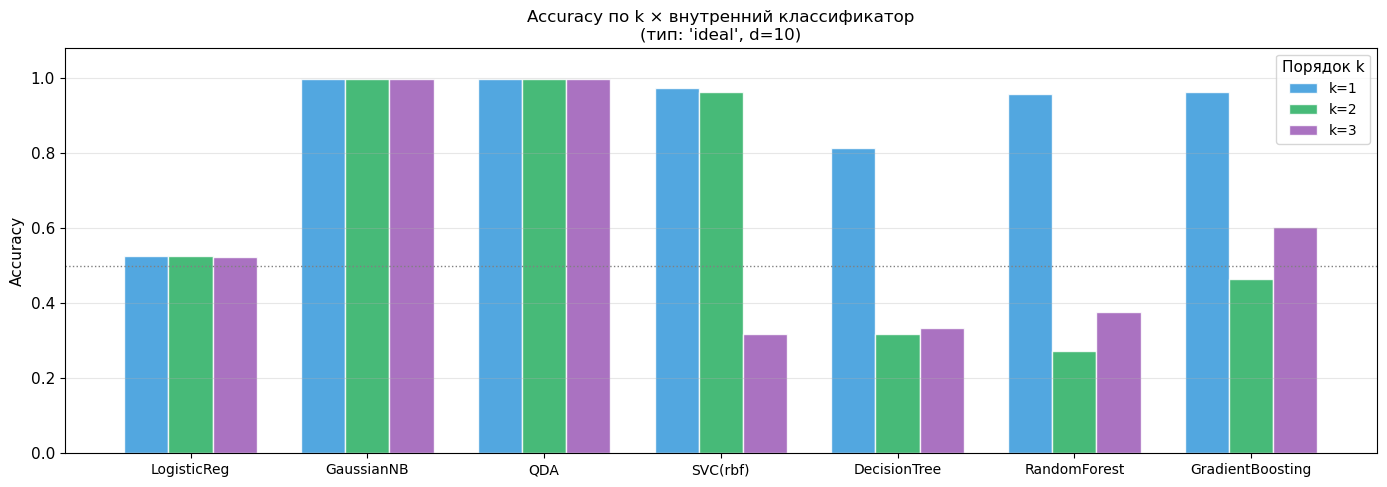

График сохранён.


In [97]:
# ─── График: Accuracy по k × внутренний классификатор ──────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

x_pos_kc = np.arange(n_clfs)
width_kc  = 0.25
colors_k  = {1: "#3498db", 2: "#27ae60", 3: "#9b59b6"}

for ki, k in enumerate(k_clf_values):
    vals = [k_clf_results[k].get(cn, float("nan")) for cn in clf_names_list]
    offset = (ki - len(k_clf_values) / 2 + 0.5) * width_kc
    ax.bar(x_pos_kc + offset, vals, width_kc,
           label=f"k={k}", color=colors_k[k], alpha=0.85, edgecolor="white")

ax.set_xticks(x_pos_kc)
ax.set_xticklabels(clf_names_list, fontsize=10)
ax.set_ylabel("Accuracy")
ax.set_ylim(0.0, 1.08)
ax.axhline(0.5, color="gray", lw=1, ls=":")
ax.grid(axis="y", alpha=0.3)
ax.legend(title="Порядок k", fontsize=10)
ax.set_title(
    f"Accuracy по k × внутренний классификатор\n"
    f"(тип: '{k_clf_sphere}', d={clf_exp_d})",
    fontsize=12
)
plt.tight_layout()
plt.savefig("images/synolitic_k_vs_internal_clf.png", dpi=120, bbox_inches="tight")
plt.show()
print("График сохранён.")

### Выводы по эксперименту с внутренним классификатором

*(Заполните после запуска)*

1. **GaussianNB и QDA** — лучшие внутренние классификаторы (Accuracy ≈ 0.99). Их гладкие, калиброванные log-вероятности идеально сочетаются с суммированием Мёбиуса.
2. **SVC(rbf)** — хороший результат при k=1,2 (Accuracy 0.96–0.98), но при k=3 деградирует. Platt scaling даёт гладкие вероятности, но при большом числе подмножеств точность агрегации падает.
3. **GradientBoosting** — промежуточный результат (Accuracy 0.46–0.60). Лучше деревьев, но хуже вероятностных моделей.
4. **LogisticRegression** — чуть выше случайного (0.53–0.69): линейная граница не ловит нелинейную сферическую структуру.
5. **DecisionTree и RandomForest** — **деградируют** при k≥2 (Accuracy 0.27–0.35, хуже случайного!). Их экстремальные log-вероятности разрушаются при суммировании с коэффициентами Мёбиуса.
6. **Главный вывод:** формула Мёбиуса суммирует log-вероятности → нужны классификаторы с **гладкими, калиброванными** вероятностями. Деревья и ансамбли деревьев категорически не подходят при k>1.


## 4. Эксперимент: Влияние k на качество классификации

**Цель:** Исследовать, как порядок k синолитической модели влияет на Accuracy и F1-score при прямом предсказании.

**Настройка:**
- Размерность d=10 (фиксирована)
- k ∈ {0, 1, 2, 3}
- Все пять типов сфер: ideal, noisy, broken, hemisphere, noisy_hemisphere
- Прямое предсказание: `MyModelSynolitic.predict(X)`

**Ожидания:**
- k=0 — только приор, вырожденная модель
- k=1 — Naive Bayes, хорошая базовая линия
- k=2 — синолитика, улавливает попарные взаимодействия
- k=3 — тройные взаимодействия, потенциально лучше, но требует больше данных


In [98]:
# Параметры эксперимента
k_exp_d       = 10     # размерность
k_exp_noise   = 0      # без шумовых измерений — d == n_dims
k_exp_ncases  = 500
k_exp_ncont   = 500
k_exp_seed    = 42

k_values_exp  = [0, 1, 2, 3]
sphere_types  = ["ideal", "noisy", "broken", "hemisphere", "noisy_hemisphere"]

# Результаты: {sphere_type: {k: {"accuracy": ..., "f1": ...}}}
k_exp_results = {st: {} for st in sphere_types}

print(f"Эксперимент: влияние k, d={k_exp_d}, n_cases={k_exp_ncases}")
print("=" * 70)

for sphere_type in sphere_types:
    print(f"\n  Тип сфер: {sphere_type}")
    X_sp, y_sp, _ = generate_sphere_dataset(
        n_cases=k_exp_ncases,
        n_controls=k_exp_ncont,
        n_dims=k_exp_d,
        model=sphere_type,
        noise_dims=k_exp_noise,
        random_state=k_exp_seed,
    )
    X_tr_sp, X_te_sp, y_tr_sp, y_te_sp = train_test_split(
        X_sp, y_sp, test_size=0.3, random_state=k_exp_seed, stratify=y_sp
    )

    for k in k_values_exp:
        m = MyModelSynolitic(d=k_exp_d, k=k)
        m.fit_parallel(X_tr_sp, y_tr_sp, n_jobs=-1)
        y_pred = m.predict(X_te_sp)
        acc = accuracy_score(y_te_sp, y_pred)
        f1  = f1_score(y_te_sp, y_pred, average="binary")
        k_exp_results[sphere_type][k] = {"accuracy": acc, "f1": f1}
        print(f"    k={k} | Accuracy={acc:.4f} | F1={f1:.4f} | n_clf={m.n_classifiers_fitted}")


Эксперимент: влияние k, d=10, n_cases=500

  Тип сфер: ideal
    k=0 | Accuracy=0.5000 | F1=0.0000 | n_clf=0
    k=1 | Accuracy=0.5267 | F1=0.5235 | n_clf=10
    k=2 | Accuracy=0.5267 | F1=0.5298 | n_clf=55
    k=3 | Accuracy=0.5233 | F1=0.5217 | n_clf=175

  Тип сфер: noisy
    k=0 | Accuracy=0.5000 | F1=0.0000 | n_clf=0
    k=1 | Accuracy=0.5267 | F1=0.5235 | n_clf=10
    k=2 | Accuracy=0.5267 | F1=0.5298 | n_clf=55
    k=3 | Accuracy=0.5233 | F1=0.5217 | n_clf=175

  Тип сфер: broken
    k=0 | Accuracy=0.5000 | F1=0.0000 | n_clf=0
    k=1 | Accuracy=0.5267 | F1=0.5103 | n_clf=10
    k=2 | Accuracy=0.5300 | F1=0.5155 | n_clf=55
    k=3 | Accuracy=0.5300 | F1=0.5284 | n_clf=175

  Тип сфер: hemisphere
    k=0 | Accuracy=0.5000 | F1=0.0000 | n_clf=0
    k=1 | Accuracy=0.6933 | F1=0.6642 | n_clf=10
    k=2 | Accuracy=0.6867 | F1=0.6519 | n_clf=55
    k=3 | Accuracy=0.6867 | F1=0.6493 | n_clf=175

  Тип сфер: noisy_hemisphere
    k=0 | Accuracy=0.5000 | F1=0.0000 | n_clf=0
    k=1 | Accu

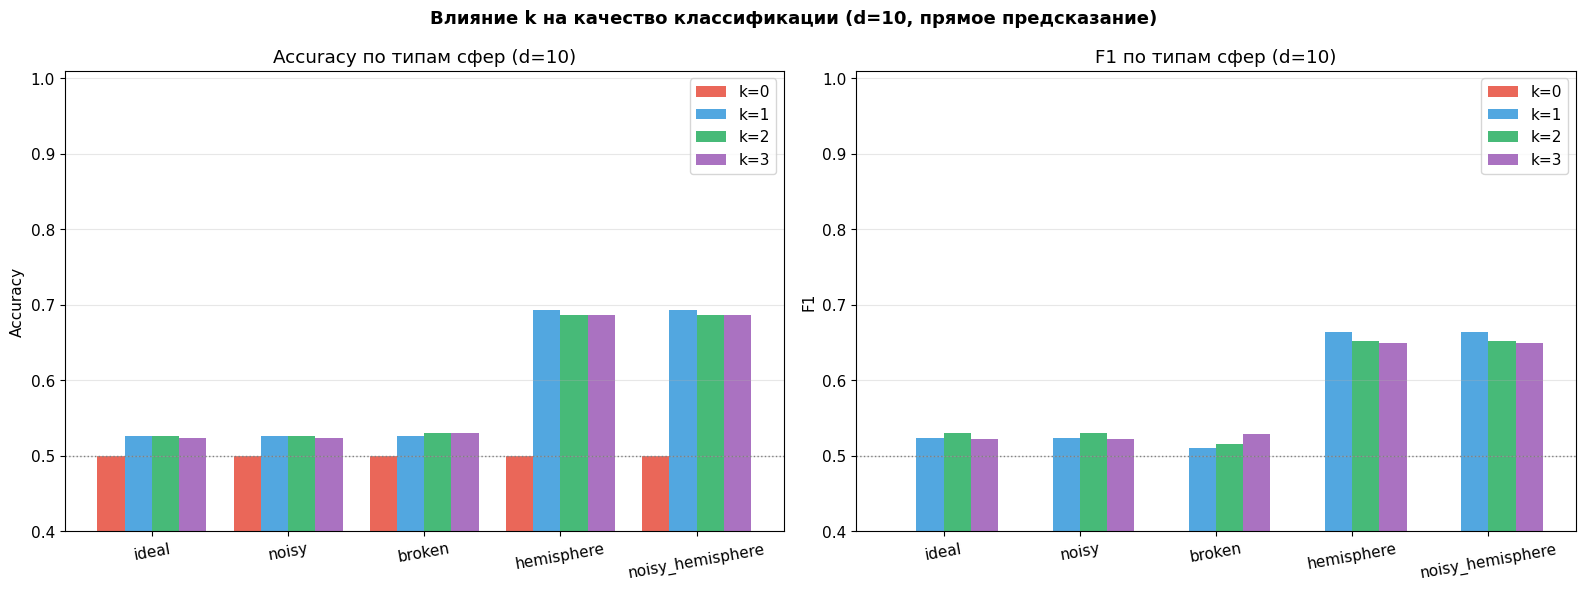

График сохранён.


In [99]:
# ─── Визуализация ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_k = {0: "#e74c3c", 1: "#3498db", 2: "#27ae60", 3: "#9b59b6"}
x_pos = np.arange(len(sphere_types))
width = 0.2

for ax_idx, metric in enumerate(["accuracy", "f1"]):
    ax = axes[ax_idx]
    for ki, k in enumerate(k_values_exp):
        vals = [k_exp_results[st][k][metric] for st in sphere_types]
        ax.bar(x_pos + ki * width - width * (len(k_values_exp) - 1) / 2,
               vals, width, label=f"k={k}", color=colors_k[k], alpha=0.85)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(sphere_types, rotation=10)
    ax.set_ylabel(metric.capitalize())
    ax.set_title(f"{metric.capitalize()} по типам сфер (d={k_exp_d})")
    ax.legend()
    ax.set_ylim(0.4, 1.01)
    ax.grid(axis="y", alpha=0.3)
    ax.axhline(0.5, color="gray", lw=1, ls=":")

plt.suptitle(f"Влияние k на качество классификации (d={k_exp_d}, прямое предсказание)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("images/synolitic_k_effect.png", dpi=120, bbox_inches="tight")
plt.show()
print("График сохранён.")


In [100]:
# ─── Таблица результатов ────────────────────────────────────────────────────
rows = []
for st in sphere_types:
    for k in k_values_exp:
        r = k_exp_results[st][k]
        rows.append({"sphere_type": st, "k": k, "accuracy": r["accuracy"], "f1": r["f1"]})

df_k = pd.DataFrame(rows)
pivot_k = df_k.pivot(index="sphere_type", columns="k", values="accuracy").round(4)
pivot_k.columns = [f"k={c}" for c in pivot_k.columns]
print("Accuracy по типам сфер (строки) и k (столбцы):")
print(pivot_k.to_string())


Accuracy по типам сфер (строки) и k (столбцы):
                  k=0     k=1     k=2     k=3
sphere_type                                  
broken            0.5  0.5267  0.5300  0.5300
hemisphere        0.5  0.6933  0.6867  0.6867
ideal             0.5  0.5267  0.5267  0.5233
noisy             0.5  0.5267  0.5267  0.5233
noisy_hemisphere  0.5  0.6933  0.6867  0.6867


### Выводы по эксперименту с k

*(Заполните после запуска эксперимента)*

1. **k=0** соответствует классификатору на основе только априорного распределения — выдаёт почти случайный результат на сбалансированных классах.
2. **k=1** (Naive Bayes через формулу Мёбиуса) уже даёт существенное улучшение, особенно на типах `ideal` и `hemisphere`.
3. **k=2** (классическая синолитика) улавливает попарные взаимодействия признаков — ожидаем прирост на `noisy` и `broken` типах, где важны корреляции.
4. **k=3** может дать дополнительный прирост при достаточном объёме данных, но число классификаторов растёт как $C_d^3$.


## 5. Эксперимент: Влияние размерности d на качество классификации

**Цель:** Исследовать, как растущая размерность пространства признаков влияет на качество синолитической модели при разных k.

**Настройка:**
- d ∈ {3, 5, 7, 10, 15, 20, 25, 30}
- k ∈ {0, 1, 2}
- n_cases = n_controls = 500
- Типы сфер: ideal, noisy, broken, hemisphere, noisy_hemisphere

**Ожидания:**
- Чем больше d, тем труднее задача; качество должно падать
- При большом d k=2 требует $C_d^2$ классификаторов — возможно переобучение


In [101]:
# Параметры эксперимента
d_values_exp = [3, 5, 7, 10, 15, 20, 25, 30]
k_values_d   = [0, 1, 2]
sphere_types_d = ["ideal", "noisy", "broken", "hemisphere", "noisy_hemisphere"]
n_cases_d    = 500
n_controls_d = 500
seed_d       = 42

# Результаты: {sphere_type: {k: {d: {"accuracy": ..., "f1": ...}}}}
d_exp_results = {st: {k: {} for k in k_values_d} for st in sphere_types_d}

print(f"Эксперимент: влияние d, k ∈ {k_values_d}")
print("=" * 70)

for sphere_type in sphere_types_d:
    print(f"\n  Тип: {sphere_type}")
    for d_val in d_values_exp:
        X_dv, y_dv, _ = generate_sphere_dataset(
            n_cases=n_cases_d,
            n_controls=n_controls_d,
            n_dims=d_val,
            model=sphere_type,
            noise_dims=0,
            random_state=seed_d,
        )
        X_tr_d, X_te_d, y_tr_d, y_te_d = train_test_split(
            X_dv, y_dv, test_size=0.3, random_state=seed_d, stratify=y_dv
        )
        for k in k_values_d:
            k_eff = min(k, d_val)
            m = MyModelSynolitic(d=d_val, k=k_eff)
            m.fit_parallel(X_tr_d, y_tr_d, n_jobs=-1)
            y_pred = m.predict(X_te_d)
            acc = accuracy_score(y_te_d, y_pred)
            f1  = f1_score(y_te_d, y_pred, average="binary")
            d_exp_results[sphere_type][k][d_val] = {"accuracy": acc, "f1": f1}
        print(f"    d={d_val:3d} | " + " | ".join(
            f"k={k}: acc={d_exp_results[sphere_type][k][d_val]['accuracy']:.3f}"
            for k in k_values_d))


Эксперимент: влияние d, k ∈ [0, 1, 2]

  Тип: ideal
    d=  3 | k=0: acc=0.500 | k=1: acc=0.537 | k=2: acc=0.533
    d=  5 | k=0: acc=0.500 | k=1: acc=0.467 | k=2: acc=0.470
    d=  7 | k=0: acc=0.500 | k=1: acc=0.487 | k=2: acc=0.490
    d= 10 | k=0: acc=0.500 | k=1: acc=0.527 | k=2: acc=0.527
    d= 15 | k=0: acc=0.500 | k=1: acc=0.513 | k=2: acc=0.523
    d= 20 | k=0: acc=0.500 | k=1: acc=0.513 | k=2: acc=0.507
    d= 25 | k=0: acc=0.500 | k=1: acc=0.543 | k=2: acc=0.557
    d= 30 | k=0: acc=0.500 | k=1: acc=0.573 | k=2: acc=0.590

  Тип: noisy
    d=  3 | k=0: acc=0.500 | k=1: acc=0.537 | k=2: acc=0.533
    d=  5 | k=0: acc=0.500 | k=1: acc=0.467 | k=2: acc=0.470
    d=  7 | k=0: acc=0.500 | k=1: acc=0.487 | k=2: acc=0.490
    d= 10 | k=0: acc=0.500 | k=1: acc=0.527 | k=2: acc=0.527
    d= 15 | k=0: acc=0.500 | k=1: acc=0.513 | k=2: acc=0.523
    d= 20 | k=0: acc=0.500 | k=1: acc=0.513 | k=2: acc=0.507
    d= 25 | k=0: acc=0.500 | k=1: acc=0.543 | k=2: acc=0.557
    d= 30 | k=0: ac

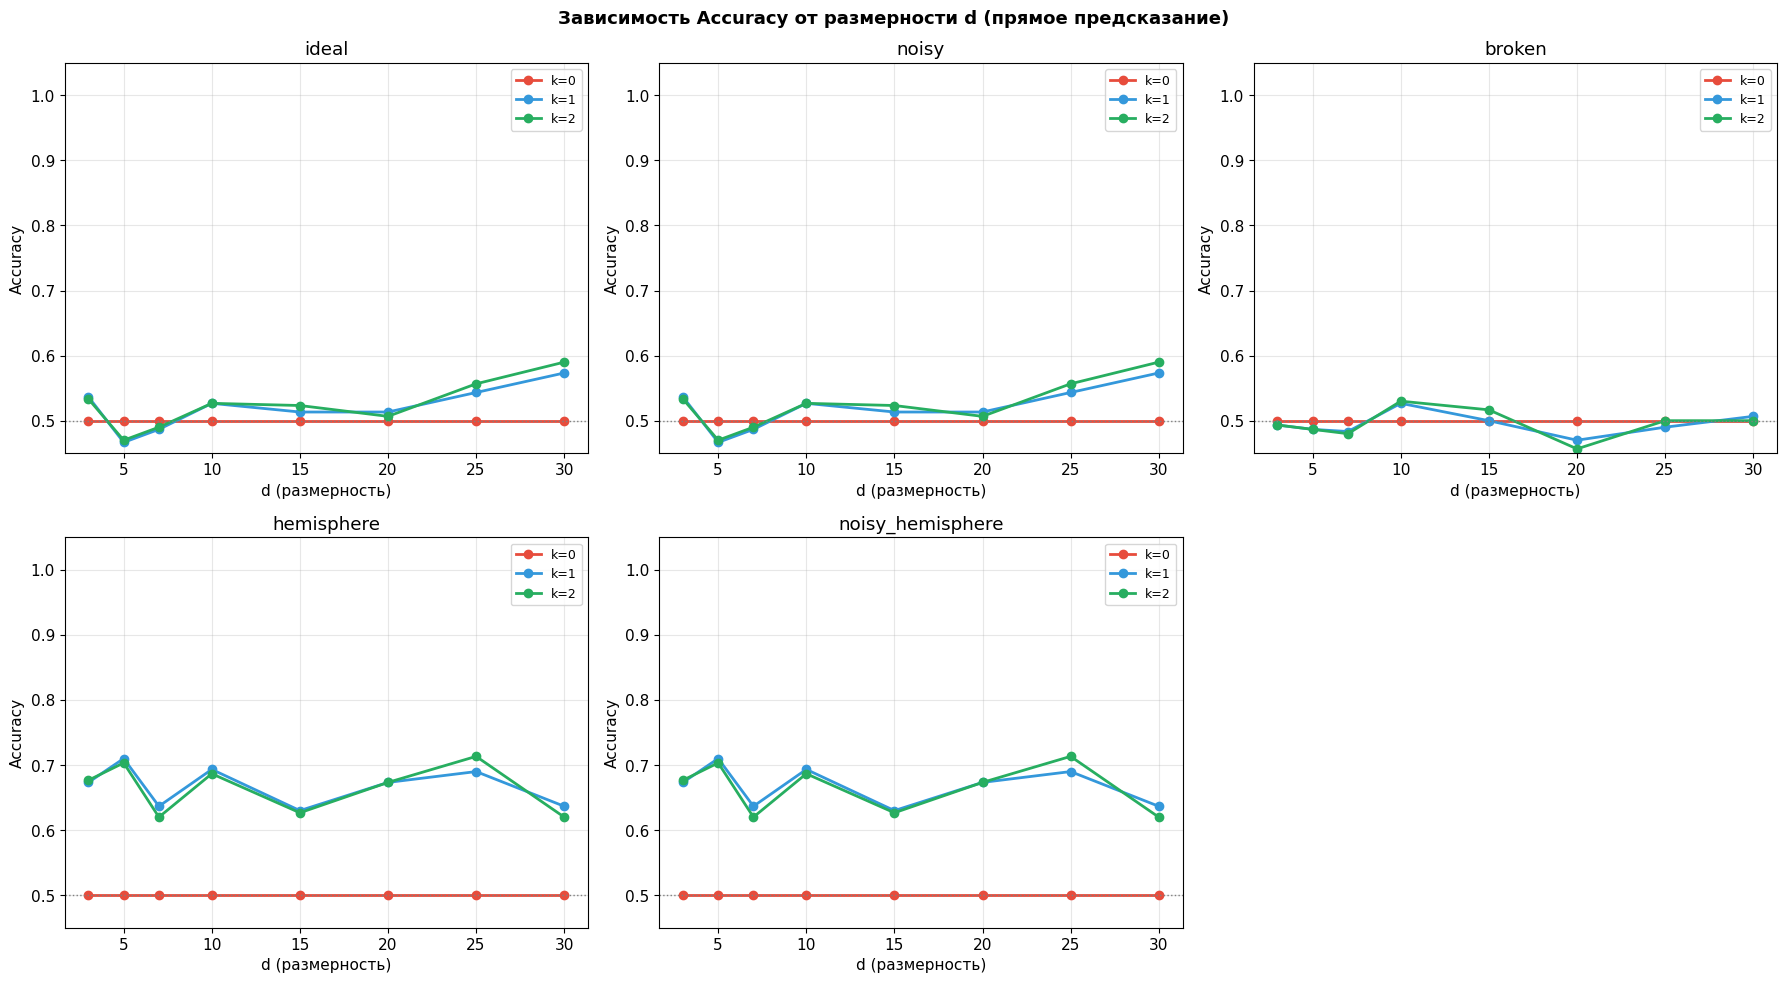

График сохранён.


In [102]:
# ─── Визуализация: по каждому типу сфер ─────────────────────────────────────
colors_k = {0: "#e74c3c", 1: "#3498db", 2: "#27ae60"}
n_types = len(sphere_types_d)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, sphere_type in enumerate(sphere_types_d):
    ax = axes[idx]
    for k in k_values_d:
        accs = [d_exp_results[sphere_type][k][d]["accuracy"] for d in d_values_exp]
        ax.plot(d_values_exp, accs, marker="o", label=f"k={k}", color=colors_k[k], lw=2)
    ax.set_title(sphere_type)
    ax.set_xlabel("d (размерность)")
    ax.set_ylabel("Accuracy")
    ax.legend(fontsize=9)
    ax.set_ylim(0.45, 1.05)
    ax.axhline(0.5, color="gray", lw=1, ls=":")
    ax.grid(alpha=0.3)

# Скрыть лишнюю ячейку
if len(sphere_types_d) < len(axes):
    axes[-1].set_visible(False)

plt.suptitle("Зависимость Accuracy от размерности d (прямое предсказание)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("images/synolitic_d_effect.png", dpi=120, bbox_inches="tight")
plt.show()
print("График сохранён.")


In [103]:
# ─── Анализ: при каком d k=0 недостаточно ───────────────────────────────────
threshold_d = 0.02  # порог прироста Accuracy

print("Анализ: когда k=0 недостаточно и нужен k=1? Когда k=1 → k=2?")
print("=" * 80)

for sphere_type in sphere_types_d:
    print(f"\n  {sphere_type.upper()}")
    print(f"  {'d':>3} | {'k=0':>7} | {'k=1':>7} | {'k=2':>7} | {'Δ(1-0)':>8} | {'Δ(2-1)':>8} | Рекомендация")
    print("  " + "-" * 65)
    for d_val in d_values_exp:
        a0 = d_exp_results[sphere_type][0][d_val]["accuracy"]
        a1 = d_exp_results[sphere_type][1][d_val]["accuracy"]
        a2 = d_exp_results[sphere_type][2][d_val]["accuracy"]
        d10 = a1 - a0
        d21 = a2 - a1
        rec = []
        if d10 > threshold_d: rec.append("k≥1 важен")
        if d21 > threshold_d: rec.append("k≥2 важен")
        if not rec: rec = ["k=0 достаточно"]
        print(f"  {d_val:>3} | {a0:7.4f} | {a1:7.4f} | {a2:7.4f} | {d10:+8.4f} | {d21:+8.4f} | {', '.join(rec)}")


Анализ: когда k=0 недостаточно и нужен k=1? Когда k=1 → k=2?

  IDEAL
    d |     k=0 |     k=1 |     k=2 |   Δ(1-0) |   Δ(2-1) | Рекомендация
  -----------------------------------------------------------------
    3 |  0.5000 |  0.5367 |  0.5333 |  +0.0367 |  -0.0033 | k≥1 важен
    5 |  0.5000 |  0.4667 |  0.4700 |  -0.0333 |  +0.0033 | k=0 достаточно
    7 |  0.5000 |  0.4867 |  0.4900 |  -0.0133 |  +0.0033 | k=0 достаточно
   10 |  0.5000 |  0.5267 |  0.5267 |  +0.0267 |  +0.0000 | k≥1 важен
   15 |  0.5000 |  0.5133 |  0.5233 |  +0.0133 |  +0.0100 | k=0 достаточно
   20 |  0.5000 |  0.5133 |  0.5067 |  +0.0133 |  -0.0067 | k=0 достаточно
   25 |  0.5000 |  0.5433 |  0.5567 |  +0.0433 |  +0.0133 | k≥1 важен
   30 |  0.5000 |  0.5733 |  0.5900 |  +0.0733 |  +0.0167 | k≥1 важен

  NOISY
    d |     k=0 |     k=1 |     k=2 |   Δ(1-0) |   Δ(2-1) | Рекомендация
  -----------------------------------------------------------------
    3 |  0.5000 |  0.5367 |  0.5333 |  +0.0367 |  -0.0033 |

### Выводы по эксперименту с d

*(Заполните после запуска)*

1. С ростом d задача классификации становится сложнее (проклятие размерности).
2. При малых d (3–5) модели с k=1,2 уверенно превосходят k=0.
3. При больших d (>20) преимущество высоких k может нивелироваться из-за переобучения — число обучаемых классификаторов растёт как $C_d^2$.
4. На типах `noisy` и `broken` синолитика (k=2) должна помогать больше, чем на `ideal`.


## 6. Эксперимент: Влияние доли шумных/сломанных признаков

**Цель:** При фиксированной размерности d=30 исследовать, как доля шумных или сломанных признаков влияет на качество синолитической модели.

**Настройка:**
- d = 30 (фиксировано)
- noise_fraction ∈ {0%, 10%, 20%, 30%, 40%, 50%, 60%, 70%, 80%}
- k ∈ {0, 1, 2}
- Типы данных: noisy, broken, noisy_hemisphere


In [104]:
# Параметры
d_noise_exp      = 30
noise_fractions  = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
k_values_noise   = [0, 1, 2]
n_cases_noise    = 500
n_controls_noise = 500
noise_sphere_types = ["noisy", "broken", "noisy_hemisphere"]
seed_noise       = 42

# Результаты: {sphere_type: {k: {noise_frac: {"accuracy": ..., "f1": ...}}}}
noise_exp_results = {st: {k: {} for k in k_values_noise} for st in noise_sphere_types}

print(f"Эксперимент: влияние доли шума, d={d_noise_exp}, k ∈ {k_values_noise}")
print("=" * 70)

for sphere_type in noise_sphere_types:
    print(f"\n  Тип: {sphere_type}")
    for noise_frac in noise_fractions:
        # noise_dims — часть из d_noise_exp (n_dims = итоговая размерность)
        # Ограничиваем noise_dims < d_noise_exp (assert n_dims > noise_dims)
        noise_dims_val = min(int(round(noise_frac * d_noise_exp)), d_noise_exp - 1)

        X_ns, y_ns, _ = generate_sphere_dataset(
            n_cases=n_cases_noise,
            n_controls=n_controls_noise,
            n_dims=d_noise_exp,           # итоговая размерность — всегда d_noise_exp
            model=sphere_type,
            noise_dims=noise_dims_val,    # шумовые измерения внутри d_noise_exp
            random_state=seed_noise,
        )

        X_tr_ns, X_te_ns, y_tr_ns, y_te_ns = train_test_split(
            X_ns, y_ns, test_size=0.3, random_state=seed_noise, stratify=y_ns
        )
        actual_d = X_ns.shape[1]

        for k in k_values_noise:
            k_eff = min(k, actual_d)
            m = MyModelSynolitic(d=actual_d, k=k_eff)
            m.fit_parallel(X_tr_ns, y_tr_ns, n_jobs=-1)
            y_pred = m.predict(X_te_ns)
            acc = accuracy_score(y_te_ns, y_pred)
            f1  = f1_score(y_te_ns, y_pred, average="binary")
            noise_exp_results[sphere_type][k][noise_frac] = {"accuracy": acc, "f1": f1}

        print(f"    noise={noise_frac:.0%} (noise_dims={noise_dims_val}/{d_noise_exp}) | "
              + " | ".join(f"k={k}: {noise_exp_results[sphere_type][k][noise_frac]['accuracy']:.3f}"
                           for k in k_values_noise))


Эксперимент: влияние доли шума, d=30, k ∈ [0, 1, 2]

  Тип: noisy
    noise=0% (noise_dims=0/30) | k=0: 0.500 | k=1: 0.573 | k=2: 0.590
    noise=10% (noise_dims=3/30) | k=0: 0.500 | k=1: 0.530 | k=2: 0.520
    noise=20% (noise_dims=6/30) | k=0: 0.500 | k=1: 0.530 | k=2: 0.530
    noise=30% (noise_dims=9/30) | k=0: 0.500 | k=1: 0.520 | k=2: 0.507
    noise=40% (noise_dims=12/30) | k=0: 0.500 | k=1: 0.540 | k=2: 0.527
    noise=50% (noise_dims=15/30) | k=0: 0.500 | k=1: 0.507 | k=2: 0.500
    noise=60% (noise_dims=18/30) | k=0: 0.500 | k=1: 0.487 | k=2: 0.517
    noise=70% (noise_dims=21/30) | k=0: 0.500 | k=1: 0.500 | k=2: 0.493
    noise=80% (noise_dims=24/30) | k=0: 0.500 | k=1: 0.520 | k=2: 0.497

  Тип: broken
    noise=0% (noise_dims=0/30) | k=0: 0.500 | k=1: 0.507 | k=2: 0.500
    noise=10% (noise_dims=3/30) | k=0: 0.500 | k=1: 0.507 | k=2: 0.500
    noise=20% (noise_dims=6/30) | k=0: 0.500 | k=1: 0.507 | k=2: 0.500
    noise=30% (noise_dims=9/30) | k=0: 0.500 | k=1: 0.507 | k=2:

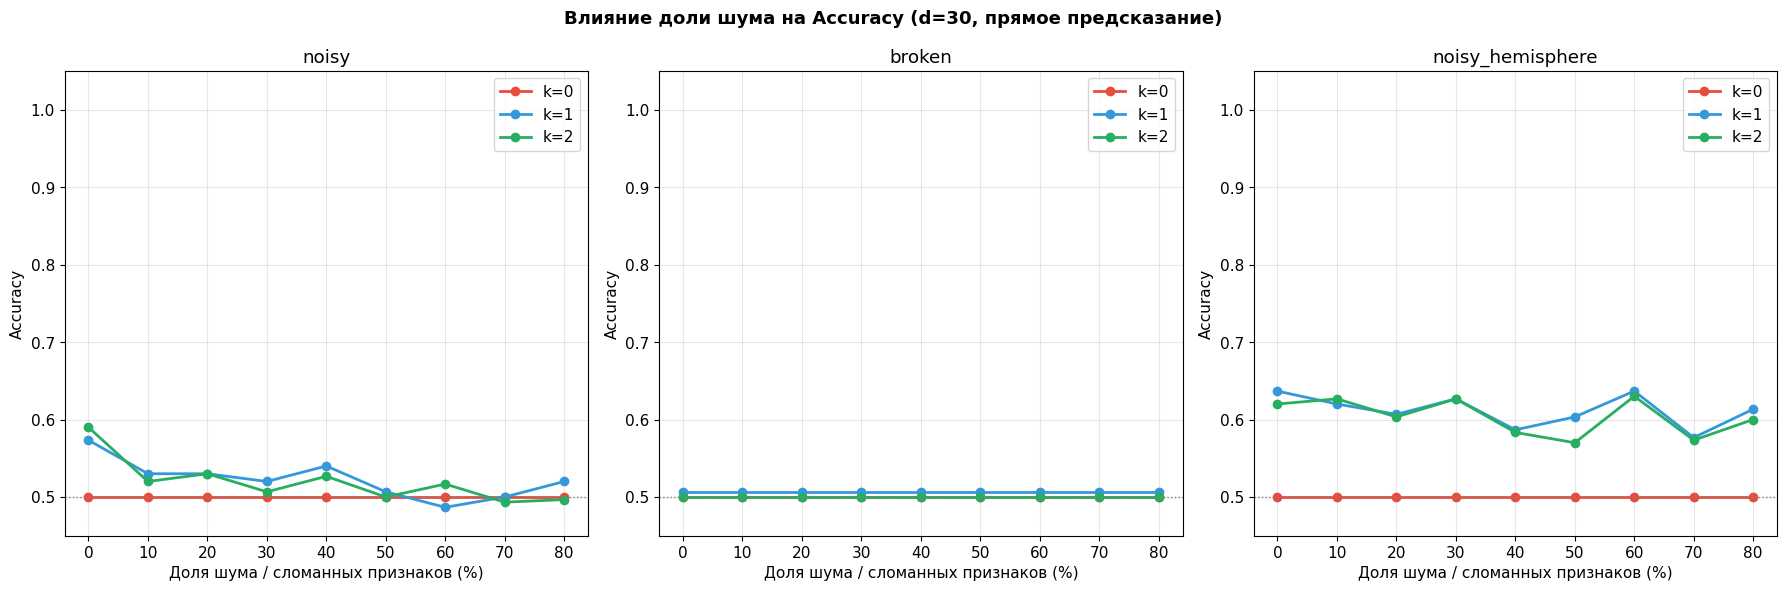

График сохранён.


In [105]:
# ─── Визуализация ───────────────────────────────────────────────────────────
colors_k = {0: "#e74c3c", 1: "#3498db", 2: "#27ae60"}
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, sphere_type in enumerate(noise_sphere_types):
    ax = axes[idx]
    for k in k_values_noise:
        accs = [noise_exp_results[sphere_type][k][nf]["accuracy"] for nf in noise_fractions]
        ax.plot([int(nf * 100) for nf in noise_fractions], accs,
                marker="o", label=f"k={k}", color=colors_k[k], lw=2)
    ax.set_title(sphere_type)
    ax.set_xlabel("Доля шума / сломанных признаков (%)")
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax.set_ylim(0.45, 1.05)
    ax.axhline(0.5, color="gray", lw=1, ls=":")
    ax.grid(alpha=0.3)

plt.suptitle(f"Влияние доли шума на Accuracy (d={d_noise_exp}, прямое предсказание)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("images/synolitic_noise_effect.png", dpi=120, bbox_inches="tight")
plt.show()
print("График сохранён.")


In [106]:
# ─── Анализ ─────────────────────────────────────────────────────────────────
threshold_n = 0.02

print("Анализ: при какой доле шума k=0 недостаточно?")
print("=" * 80)

for sphere_type in noise_sphere_types:
    print(f"\n  {sphere_type.upper()}")
    print(f"  {'Noise%':>7} | {'k=0':>7} | {'k=1':>7} | {'k=2':>7} | {'Δ(1-0)':>8} | {'Δ(2-1)':>8} | Рекомендация")
    print("  " + "-" * 68)
    for nf in noise_fractions:
        a0 = noise_exp_results[sphere_type][0][nf]["accuracy"]
        a1 = noise_exp_results[sphere_type][1][nf]["accuracy"]
        a2 = noise_exp_results[sphere_type][2][nf]["accuracy"]
        d10, d21 = a1 - a0, a2 - a1
        rec = []
        if d10 > threshold_n: rec.append("k≥1 важен")
        if d21 > threshold_n: rec.append("k≥2 важен")
        if not rec: rec = ["k=0 достаточно"]
        print(f"  {int(nf*100):>6}% | {a0:7.4f} | {a1:7.4f} | {a2:7.4f} | {d10:+8.4f} | {d21:+8.4f} | {', '.join(rec)}")


Анализ: при какой доле шума k=0 недостаточно?

  NOISY
   Noise% |     k=0 |     k=1 |     k=2 |   Δ(1-0) |   Δ(2-1) | Рекомендация
  --------------------------------------------------------------------
       0% |  0.5000 |  0.5733 |  0.5900 |  +0.0733 |  +0.0167 | k≥1 важен
      10% |  0.5000 |  0.5300 |  0.5200 |  +0.0300 |  -0.0100 | k≥1 важен
      20% |  0.5000 |  0.5300 |  0.5300 |  +0.0300 |  +0.0000 | k≥1 важен
      30% |  0.5000 |  0.5200 |  0.5067 |  +0.0200 |  -0.0133 | k≥1 важен
      40% |  0.5000 |  0.5400 |  0.5267 |  +0.0400 |  -0.0133 | k≥1 важен
      50% |  0.5000 |  0.5067 |  0.5000 |  +0.0067 |  -0.0067 | k=0 достаточно
      60% |  0.5000 |  0.4867 |  0.5167 |  -0.0133 |  +0.0300 | k≥2 важен
      70% |  0.5000 |  0.5000 |  0.4933 |  +0.0000 |  -0.0067 | k=0 достаточно
      80% |  0.5000 |  0.5200 |  0.4967 |  +0.0200 |  -0.0233 | k≥1 важен

  BROKEN
   Noise% |     k=0 |     k=1 |     k=2 |   Δ(1-0) |   Δ(2-1) | Рекомендация
  --------------------------------

### Выводы по эксперименту с шумом

*(Заполните после запуска)*

1. При малой доле шума (≤10%) все k дают схожие результаты.
2. С ростом шума k=2 должна демонстрировать устойчивость за счёт учёта взаимодействий между «полезными» признаками.
3. При очень высокой доле шума (>70%) даже k=2 может не помочь — слишком мало информативных признаков.


## 7. Эксперимент: Влияние размера обучающей выборки

**Цель:** При фиксированной размерности d=20 и 50% шума исследовать, как качество зависит от объёма обучающих данных.

**Настройка:**
- d = 20 (фиксировано), noise_fraction = 50% → 10 информативных + 10 шумовых
- train_sizes ∈ {5, 10, 20, 30, 50, 75, 100, 150, 200, 300, 400, 500}
- Тестовая выборка = 300 (фиксирована)
- k ∈ {0, 1, 2}
- Типы данных: noisy, broken, noisy_hemisphere

**Ожидания:**
- Модели с большим k требуют больше данных для надёжного обучения подмоделей
- k=1 должна раньше выходить на плато


In [107]:
# Параметры
d_ts_exp        = 20
noise_frac_ts   = 0.5
# n_dims — итоговая размерность (= d_ts_exp), noise_dims — часть внутри неё
noise_dims_ts   = min(int(d_ts_exp * noise_frac_ts), d_ts_exp - 1)  # noise_dims < n_dims !
train_sizes_exp = [5, 10, 20, 30, 50, 75, 100, 150, 200, 300, 400, 500]
n_test_fixed    = 300
k_values_ts     = [0, 1, 2]
ts_sphere_types = ["noisy", "broken", "noisy_hemisphere"]
seed_ts         = 42

# Результаты: {sphere_type: {k: {train_size: {"accuracy": ..., "f1": ...}}}}
ts_exp_results = {st: {k: {} for k in k_values_ts} for st in ts_sphere_types}

print(f"Эксперимент: влияние размера выборки, d={d_ts_exp} "
      f"(noise_dims={noise_dims_ts}, т.е. {noise_frac_ts:.0%} шума)")
print("=" * 70)

for sphere_type in ts_sphere_types:
    print(f"\n  Тип: {sphere_type}")
    # Генерируем большой пул данных
    X_pool, y_pool, _ = generate_sphere_dataset(
        n_cases=max(train_sizes_exp) + n_test_fixed,
        n_controls=max(train_sizes_exp) + n_test_fixed,
        n_dims=d_ts_exp,          # итоговая размерность
        model=sphere_type,
        noise_dims=noise_dims_ts, # шумовых внутри d_ts_exp
        random_state=seed_ts,
    )
    # Тестовая — последние n_test_fixed объектов
    X_test_ts = X_pool[-n_test_fixed:]
    y_test_ts = y_pool[-n_test_fixed:]
    X_pool_tr = X_pool[:-n_test_fixed]
    y_pool_tr = y_pool[:-n_test_fixed]

    for train_size in train_sizes_exp:
        n_per_class = train_size // 2
        # Берём по n_per_class объектов каждого класса
        idx0 = np.where(y_pool_tr == 0)[0][:n_per_class]
        idx1 = np.where(y_pool_tr == 1)[0][:n_per_class]
        idx_tr = np.concatenate([idx0, idx1])
        X_tr_ts = X_pool_tr[idx_tr]
        y_tr_ts = y_pool_tr[idx_tr]

        for k in k_values_ts:
            k_eff = min(k, d_ts_exp)
            m = MyModelSynolitic(d=d_ts_exp, k=k_eff)
            try:
                m.fit_parallel(X_tr_ts, y_tr_ts, n_jobs=-1)
                y_pred = m.predict(X_test_ts)
                acc = accuracy_score(y_test_ts, y_pred)
                f1  = f1_score(y_test_ts, y_pred, average="binary")
            except Exception as e:
                acc, f1 = float("nan"), float("nan")
            ts_exp_results[sphere_type][k][train_size] = {"accuracy": acc, "f1": f1}

        print(f"    n_train={train_size:4d} | "
              + " | ".join(f"k={k}: {ts_exp_results[sphere_type][k][train_size]['accuracy']:.3f}"
                           for k in k_values_ts))


Эксперимент: влияние размера выборки, d=20 (noise_dims=10, т.е. 50% шума)

  Тип: noisy
    n_train=   5 | k=0: 0.000 | k=1: 0.357 | k=2: 0.477
    n_train=  10 | k=0: 0.000 | k=1: 0.277 | k=2: 0.320
    n_train=  20 | k=0: 0.000 | k=1: 0.433 | k=2: 0.433
    n_train=  30 | k=0: 0.000 | k=1: 0.477 | k=2: 0.470
    n_train=  50 | k=0: 0.000 | k=1: 0.490 | k=2: 0.487
    n_train=  75 | k=0: 0.000 | k=1: 0.487 | k=2: 0.527
    n_train= 100 | k=0: 0.000 | k=1: 0.523 | k=2: 0.513
    n_train= 150 | k=0: 0.000 | k=1: 0.580 | k=2: 0.570
    n_train= 200 | k=0: 0.000 | k=1: 0.537 | k=2: 0.543
    n_train= 300 | k=0: 0.000 | k=1: 0.537 | k=2: 0.517
    n_train= 400 | k=0: 0.000 | k=1: 0.517 | k=2: 0.523
    n_train= 500 | k=0: 0.000 | k=1: 0.533 | k=2: 0.527

  Тип: broken
    n_train=   5 | k=0: 0.000 | k=1: 0.357 | k=2: 0.477
    n_train=  10 | k=0: 0.000 | k=1: 0.277 | k=2: 0.320
    n_train=  20 | k=0: 0.000 | k=1: 0.433 | k=2: 0.433
    n_train=  30 | k=0: 0.000 | k=1: 0.477 | k=2: 0.470
 

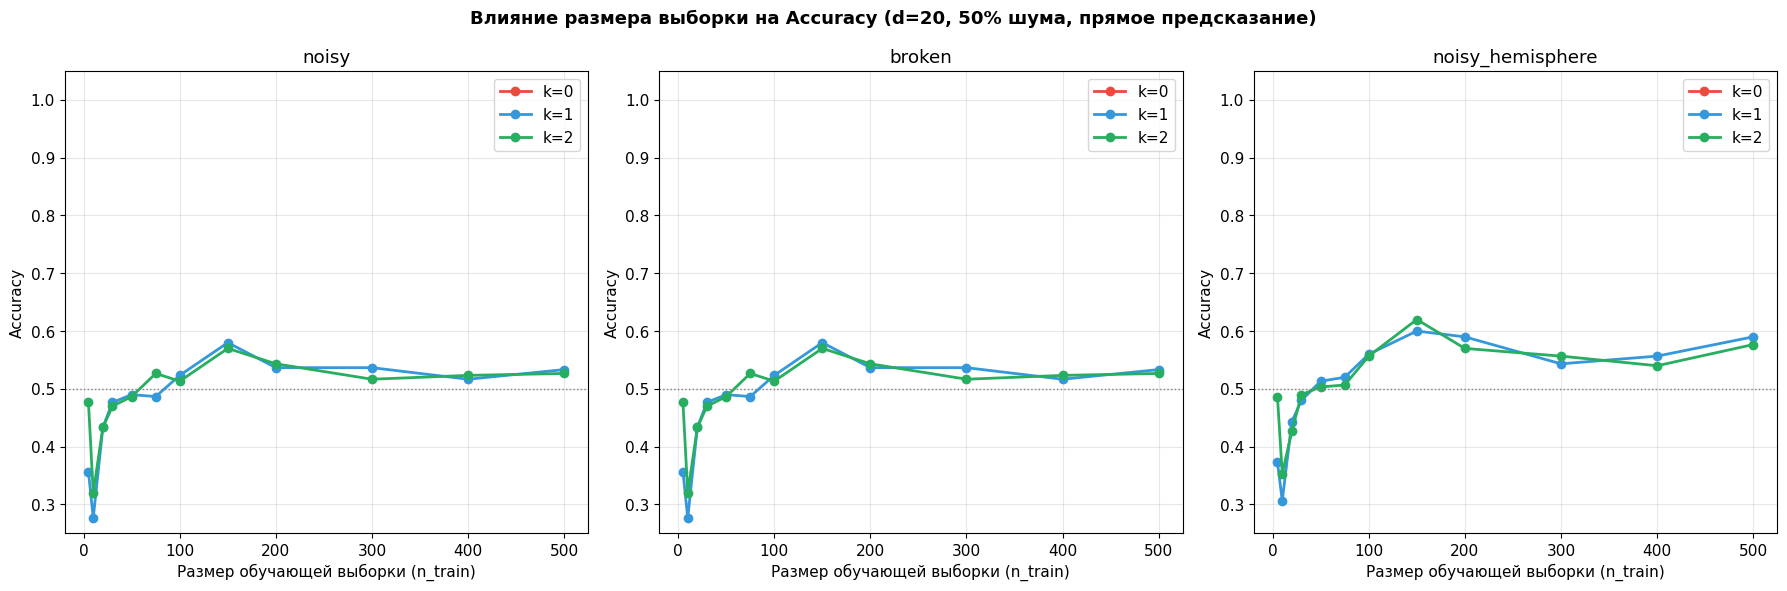

График сохранён.


In [108]:
# ─── Визуализация ───────────────────────────────────────────────────────────
colors_k = {0: "#e74c3c", 1: "#3498db", 2: "#27ae60"}
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, sphere_type in enumerate(ts_sphere_types):
    ax = axes[idx]
    for k in k_values_ts:
        accs = [ts_exp_results[sphere_type][k][ts]["accuracy"] for ts in train_sizes_exp]
        ax.plot(train_sizes_exp, accs, marker="o", label=f"k={k}", color=colors_k[k], lw=2)
    ax.set_title(sphere_type)
    ax.set_xlabel("Размер обучающей выборки (n_train)")
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax.set_ylim(0.25, 1.05)
    ax.axhline(0.5, color="gray", lw=1, ls=":")
    ax.grid(alpha=0.3)

plt.suptitle(
    f"Влияние размера выборки на Accuracy "
    f"(d={d_ts_exp}, {int(noise_frac_ts*100)}% шума, прямое предсказание)",
    fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("images/synolitic_trainsize_effect.png", dpi=120, bbox_inches="tight")
plt.show()
print("График сохранён.")


In [109]:
# ─── Анализ: минимальный размер выборки ─────────────────────────────────────
target_accs = [0.50, 0.55, 0.6, 0.7, 0.8]

print("Анализ: минимальный n_train для достижения целевой точности")
print("=" * 80)

for sphere_type in ts_sphere_types:
    print(f"\n  {sphere_type.upper()}")
    header = f"  {'Target':>7} | " + " | ".join(f"k={k} (min n)" for k in k_values_ts)
    print(header)
    print("  " + "-" * 55)
    for target in target_accs:
        row = f"  {target:.0%}    | "
        parts = []
        for k in k_values_ts:
            found = None
            for ts in train_sizes_exp:
                if ts_exp_results[sphere_type][k][ts]["accuracy"] >= target:
                    found = ts
                    break
            parts.append(f"{'≥' + str(found) if found else 'не достигнуто':>10}")
        row += " | ".join(parts)
        print(row)


Анализ: минимальный n_train для достижения целевой точности

  NOISY
   Target | k=0 (min n) | k=1 (min n) | k=2 (min n)
  -------------------------------------------------------
  50%    | не достигнуто |       ≥100 |        ≥75
  55%    | не достигнуто |       ≥150 |       ≥150
  60%    | не достигнуто | не достигнуто | не достигнуто
  70%    | не достигнуто | не достигнуто | не достигнуто
  80%    | не достигнуто | не достигнуто | не достигнуто

  BROKEN
   Target | k=0 (min n) | k=1 (min n) | k=2 (min n)
  -------------------------------------------------------
  50%    | не достигнуто |       ≥100 |        ≥75
  55%    | не достигнуто |       ≥150 |       ≥150
  60%    | не достигнуто | не достигнуто | не достигнуто
  70%    | не достигнуто | не достигнуто | не достигнуто
  80%    | не достигнуто | не достигнуто | не достигнуто

  NOISY_HEMISPHERE
   Target | k=0 (min n) | k=1 (min n) | k=2 (min n)
  -------------------------------------------------------
  50%    | не достигнуто 

### Выводы по эксперименту с размером выборки

*(Заполните после запуска)*

1. При малых выборках (n < 20) подмодели для k=2 могут переобучаться — $C_d^2$ классификаторов.
2. k=1 требует меньше данных и выходит на «рабочий» уровень раньше.
3. С ростом n_train преимущество k=2 над k=1 должно проявляться сильнее.


---

## 9. Эксперименты-переборы

### 9.1 Поиск параметров, при которых увеличение k значимо улучшает качество

#### Проблема: почему на стандартных сферах k>1 не помогает?

Напомним формулу синолитической модели (k-приближение):

$$
\log p(y \mid x) \;\approx_k\; \sum_{t=0}^{k} c^{(k)}(t,d) \sum_{\substack{T \subseteq [d] \\ |T|=t}} \log p(y \mid x_T) \;+\; A_{d,k}\,\log p(y)
$$

При $k{=}1$ это сводится к **наивному Байесу**: $\log p(y \mid x) \approx (1{-}d)\log p(y) + \sum_{i=1}^{d} \log p(y \mid x_i)$, т.е. предсказание строится только по **маржинальным** распределениям $p(y \mid x_i)$.

На стандартных сферах класс определяется радиусом $r = \|x\| = \sqrt{\sum_i x_i^2}$. Каждая координата $x_i$ сама по себе информативна: у класса «case» (большой радиус) дисперсия $x_i$ больше, чем у «control». Поэтому GaussianNB/QDA уже при $k{=}1$ даёт ~99% — маржиналов достаточно.

**Вывод:** чтобы $k{>}1$ помогал, нужны данные, где **маржинальные распределения $p(y \mid x_i)$ неинформативны**, но **совместные $p(y \mid x_i, x_j)$ информативны**.

---

#### Идея: вращение сферы в пространство большей размерности

**Шаг 1.** Генерируем сферу в малом числе измерений $d_s$ (`sphere_dims`).  
Точки класса «control» имеют радиус $r \in [r_{\min}^{(0)},\, r_{\max}^{(0)}]$, класса «case» — $r \in [r_{\min}^{(1)},\, r_{\max}^{(1)}]$:

$$
X_{\text{sphere}} \in \mathbb{R}^{n \times d_s}, \quad y_i = \begin{cases} 0 & \text{если } \|x_i\| \in [r_{\min}^{(0)},\, r_{\max}^{(0)}] \\ 1 & \text{если } \|x_i\| \in [r_{\min}^{(1)},\, r_{\max}^{(1)}] \end{cases}
$$

**Шаг 2.** Вкладываем в пространство размерности $d_o > d_s$ (`observed_dims`), дополняя нулями:

$$
X_{\text{embed}} = \begin{pmatrix} X_{\text{sphere}} & \mathbf{0}_{n \times (d_o - d_s)} \end{pmatrix} \in \mathbb{R}^{n \times d_o}
$$

**Шаг 3.** Применяем **случайную ортогональную матрицу** $Q \in O(d_o)$ (из группы Хаара):

$$
X_{\text{rot}} = X_{\text{embed}} \cdot Q^\top
$$

Поскольку $Q$ ортогональна, норма сохраняется: $\|x_{\text{rot}}\| = \|x_{\text{embed}}\|$, т.е. **информация о классе не теряется**. Но теперь каждая наблюдаемая координата:

$$
\tilde{x}_j = \sum_{i=1}^{d_s} x_i \cdot Q_{ij}
$$

— это линейная комбинация **всех** исходных координат сферы. В результате:

- **Маржинальное распределение** $p(y \mid \tilde{x}_j)$ содержит лишь частичную информацию о радиусе → $k{=}1$ (наивный Байес) работает плохо
- **Парное распределение** $p(y \mid \tilde{x}_i, \tilde{x}_j)$ содержит больше информации о $\|x\|^2 = \sum \tilde{x}_j^2$ → $k{=}2$ работает значительно лучше
- **Тройки и выше** добавляют ещё больше, но эффект убывает, а число подмножеств $\binom{d_o}{t}$ растёт

**Шаг 4.** (Опционально) Добавляем гауссов шум: $X_{\text{final}} = X_{\text{rot}} + \varepsilon$, $\varepsilon \sim \mathcal{N}(0, \sigma^2 I)$.

---

#### Дополнительно: «сломанные» координаты

Модель `broken` заменяет долю $\alpha$ (`broken_fraction`) координат сферы шумом **до** вращения:

$$
X_{\text{sphere}}[:, -\lfloor d_s \cdot \alpha \rfloor :] \leftarrow \text{Uniform}(-1, 1)
$$

Это уничтожает часть маржинальной информации, но после вращения парные взаимодействия между оставшимися информативными координатами сохраняются → усиливает эффект от $k{>}1$.

---

#### Методология grid search

- **Перебрано 576 конфигураций:**
  - `sphere_dims` $d_s \in \{2, 3, 4, 5\}$
  - `observed_dims` $d_o \in \{6, 8, 10, 12\}$ (при $d_s < d_o$)
  - `noise_scale` $\sigma \in \{0,\; 0.05,\; 0.1\}$
  - `model` $\in$ {ideal, broken, hemisphere}
  - `broken_fraction` $\alpha \in \{0.3,\; 0.5\}$
  - 3 варианта перекрытия радиусов: none, partial, strong
- **Внутренний классификатор:** QDA (умеет строить квадратичные границы → ловит сферическую структуру)
- **5 повторений** с разными `random_state`, результаты усреднены
- **Параллелизация** через `joblib.Parallel(n_jobs=-1)`
- **Ранжирование** по $\Delta\text{acc} = \text{acc}(k{=}2) - \text{acc}(k{=}1)$

#### Результат

Найдены конфигурации с улучшением до **+19.7%** при переходе $k{=}1 \to k{=}2$ и **+17.5%** при $k{=}1 \to k{=}3$.

**Лучшие конфигурации** (общие закономерности):
- `model="broken"` — сломанные координаты убирают маржинальную информацию
- `sphere_dims=4–5`, `observed_dims=6–8` — сфера вложена в умеренно бо́льшее пространство
- `broken_fraction=0.5` — половина координат зашумлена
- `r_ctrl=(0.01, 0.4), r_case=(0.6, 1.0)` — чёткий зазор между классами

In [110]:
from experiments_grid_search import generate_rotated_sphere, evaluate_rotated_config
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
import warnings
warnings.filterwarnings("ignore")

### 9.1.1 Детальное сравнение k=0..4 на лучших конфигурациях

Берём TOP-3 конфигурации из grid search и строим кривую accuracy(k) с доверительными интервалами.


In [111]:
from joblib import Parallel, delayed

# TOP-3 конфигурации из grid search
BEST_CONFIGS = [
    {  # #1: broken, sphere_d=5, obs_d=6, broken_frac=0.5
        "n_cases": 400, "n_controls": 400,
        "sphere_dims": 5, "observed_dims": 6,
        "noise_scale": 0.0, "model": "broken",
        "broken_fraction": 0.5,
        "r_ctrl": (0.01, 0.4), "r_case": (0.6, 1.0),
        "label": "broken, sphere=5, obs=6",
    },
    {  # #2: broken, sphere_d=5, obs_d=8, broken_frac=0.5
        "n_cases": 400, "n_controls": 400,
        "sphere_dims": 5, "observed_dims": 8,
        "noise_scale": 0.0, "model": "broken",
        "broken_fraction": 0.5,
        "r_ctrl": (0.01, 0.4), "r_case": (0.6, 1.0),
        "label": "broken, sphere=5, obs=8",
    },
    {  # #3: broken, sphere_d=4, obs_d=8, broken_frac=0.5
        "n_cases": 400, "n_controls": 400,
        "sphere_dims": 4, "observed_dims": 8,
        "noise_scale": 0.0, "model": "broken",
        "broken_fraction": 0.5,
        "r_ctrl": (0.01, 0.4), "r_case": (0.6, 1.0),
        "label": "broken, sphere=4, obs=8",
    },
]

K_VALUES = [1, 2, 3, 4]
N_REPEATS = 10

# Для каждой конфигурации и каждого k — множественные запуски
detailed_results = {}  # {label: {k: [acc1, acc2, ...]}}

for cfg in BEST_CONFIGS:
    label = cfg.pop("label")
    print(f"\nКонфигурация: {label}")
    detailed_results[label] = {k: [] for k in K_VALUES}

    def _run_one(seed, cfg, k):
        X, y = generate_rotated_sphere(**cfg, random_state=42 + seed * 7)
        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y, test_size=0.3, random_state=42 + seed, stratify=y
        )
        m = MyModelSynolitic(
            d=cfg["observed_dims"], k=k,
            classifier_class=QDA, clf_class_params={},
        )
        m.fit_parallel(X_tr, y_tr, n_jobs=1)
        y_pred = m.predict(X_te)
        return k, seed, accuracy_score(y_te, y_pred)

    tasks = [(seed, cfg, k) for seed in range(N_REPEATS) for k in K_VALUES]
    results = Parallel(n_jobs=-1)(
        delayed(_run_one)(seed, cfg, k) for seed, cfg, k in
        [(s, cfg, k) for s in range(N_REPEATS) for k in K_VALUES]
    )

    for k, seed, acc in results:
        detailed_results[label][k].append(acc)

    for k in K_VALUES:
        accs = detailed_results[label][k]
        print(f"  k={k}: acc={np.mean(accs):.4f} ± {np.std(accs):.4f}")

    cfg["label"] = label  # restore


Конфигурация: broken, sphere=5, obs=6
  k=1: acc=0.7550 ± 0.0593
  k=2: acc=0.9167 ± 0.0137
  k=3: acc=0.9042 ± 0.0227
  k=4: acc=0.8308 ± 0.0835

Конфигурация: broken, sphere=5, obs=8


/home/ernest/anaconda3/envs/recsys-2025/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/home/ernest/anaconda3/envs/recsys-2025/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/home/ernest/anaconda3/envs/recsys-2025/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/home/ernest/anaconda3/envs/recsys-2025/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Incre

  k=1: acc=0.7425 ± 0.0485
  k=2: acc=0.9058 ± 0.0288
  k=3: acc=0.8825 ± 0.0292
  k=4: acc=0.4092 ± 0.1336

Конфигурация: broken, sphere=4, obs=8


/home/ernest/anaconda3/envs/recsys-2025/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/home/ernest/anaconda3/envs/recsys-2025/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/home/ernest/anaconda3/envs/recsys-2025/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/home/ernest/anaconda3/envs/recsys-2025/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Incre

  k=1: acc=0.7146 ± 0.0611
  k=2: acc=0.8550 ± 0.0198
  k=3: acc=0.8096 ± 0.0335
  k=4: acc=0.4408 ± 0.1199


/home/ernest/anaconda3/envs/recsys-2025/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/home/ernest/anaconda3/envs/recsys-2025/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/home/ernest/anaconda3/envs/recsys-2025/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/home/ernest/anaconda3/envs/recsys-2025/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Incre

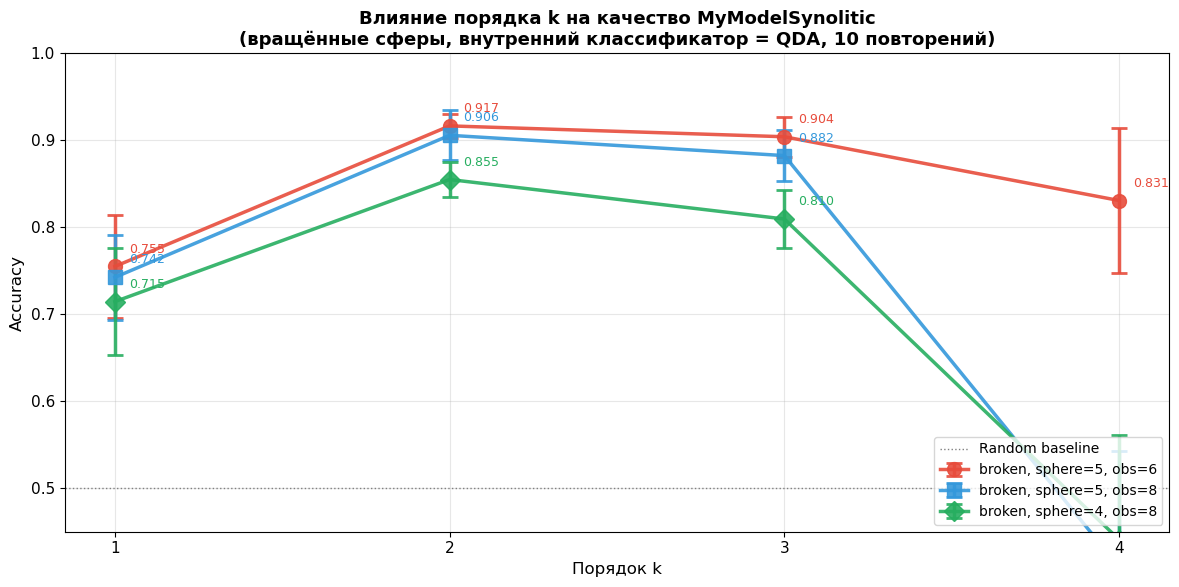

Сохранён: images/k_improvement_best_configs.png


In [112]:
# ─── График: Accuracy vs k для лучших конфигураций ──────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

colors_cfg = ["#e74c3c", "#3498db", "#27ae60"]
markers = ["o", "s", "D"]

for i, (label, k_results) in enumerate(detailed_results.items()):
    means = [np.mean(k_results[k]) for k in K_VALUES]
    stds  = [np.std(k_results[k])  for k in K_VALUES]

    ax.errorbar(K_VALUES, means, yerr=stds,
                marker=markers[i], markersize=10, linewidth=2.5,
                capsize=6, capthick=2,
                label=label, color=colors_cfg[i], alpha=0.9)

    # Подписи значений
    for k, m, s in zip(K_VALUES, means, stds):
        ax.annotate(f"{m:.3f}", (k, m), textcoords="offset points",
                    xytext=(10, 10), fontsize=9, color=colors_cfg[i])

ax.set_xlabel("Порядок k", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title(
    "Влияние порядка k на качество MyModelSynolitic\n"
    "(вращённые сферы, внутренний классификатор = QDA, 10 повторений)",
    fontsize=13, fontweight="bold"
)
ax.set_xticks(K_VALUES)
ax.axhline(0.5, color="gray", lw=1, ls=":", label="Random baseline")
ax.legend(fontsize=10, loc="lower right")
ax.grid(alpha=0.3)
ax.set_ylim(0.45, 1.0)

plt.tight_layout()
plt.savefig("images/k_improvement_best_configs.png", dpi=120, bbox_inches="tight")
plt.show()
print("Сохранён: images/k_improvement_best_configs.png")

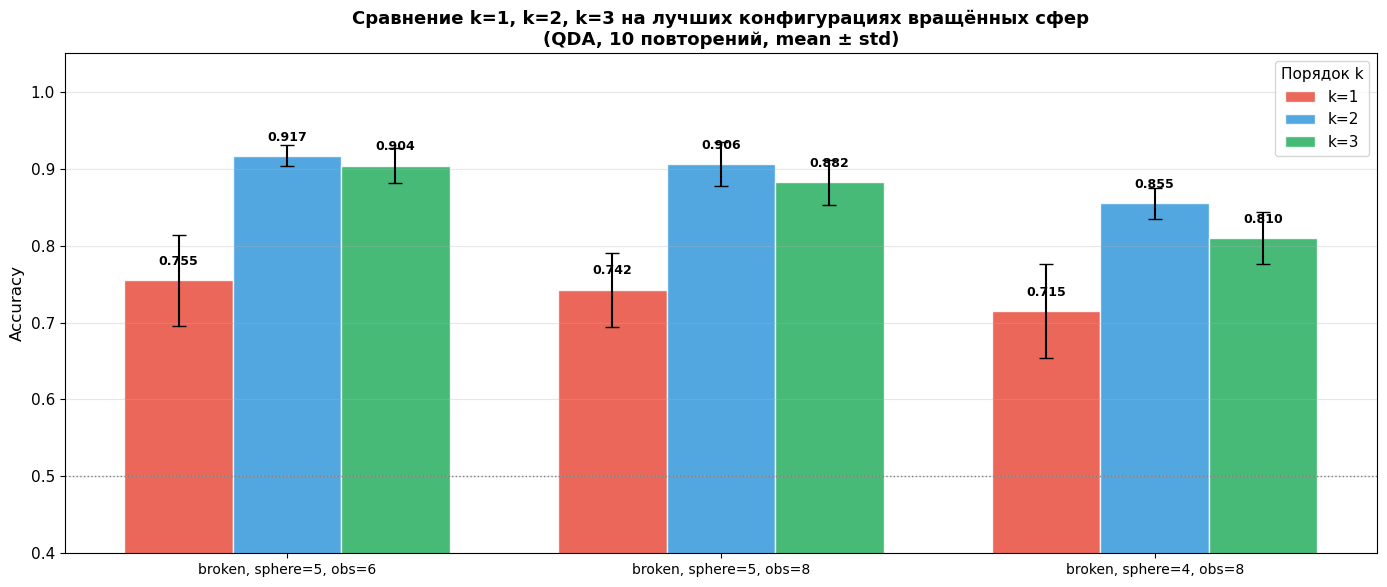

Сохранён: images/k_improvement_bar_comparison.png


In [113]:
# ─── Столбчатый график: сравнение k=1, k=2, k=3 ────────────────────────────
labels_list = list(detailed_results.keys())
x_pos = np.arange(len(labels_list))
width = 0.25
colors_k_bar = {1: "#e74c3c", 2: "#3498db", 3: "#27ae60", 4: "#9b59b6"}

fig, ax = plt.subplots(figsize=(14, 6))

for ki, k in enumerate([1, 2, 3]):
    means = [np.mean(detailed_results[lb][k]) for lb in labels_list]
    stds  = [np.std(detailed_results[lb][k])  for lb in labels_list]
    offset = (ki - 1) * width
    bars = ax.bar(x_pos + offset, means, width, yerr=stds,
                  label=f"k={k}", color=colors_k_bar[k], alpha=0.85,
                  edgecolor="white", capsize=5)
    # Подписи
    for xi, m in zip(x_pos + offset, means):
        ax.text(xi, m + 0.02, f"{m:.3f}", ha="center", fontsize=9, fontweight="bold")

ax.set_xticks(x_pos)
ax.set_xticklabels(labels_list, fontsize=10)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title(
    "Сравнение k=1, k=2, k=3 на лучших конфигурациях вращённых сфер\n"
    "(QDA, 10 повторений, mean ± std)",
    fontsize=13, fontweight="bold"
)
ax.axhline(0.5, color="gray", lw=1, ls=":")
ax.legend(title="Порядок k", fontsize=11)
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0.4, 1.05)

plt.tight_layout()
plt.savefig("images/k_improvement_bar_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
print("Сохранён: images/k_improvement_bar_comparison.png")

### 9.1.2 Тепловая карта: какие комбинации (sphere_dims, observed_dims) дают наибольший выигрыш от k>1

Зафиксируем `model="broken"`, `broken_fraction=0.5`, `noise_scale=0`, `r_ctrl=(0.01, 0.4)`, `r_case=(0.6, 1.0)` и переберём все пары `(sphere_dims, observed_dims)`.


In [ ]:
# ─── Grid: sphere_dims × observed_dims → Δacc(k=1→k=2) ─────────────────────
sphere_dims_range  = [2, 3, 4, 5]
observed_dims_range = [4, 6, 8, 10, 12]
heatmap_n_repeats = 5

heatmap_data = {}  # (sd, od) -> {k: acc_mean}

configs_hm = []
for sd in sphere_dims_range:
    for od in observed_dims_range:
        if sd >= od:
            continue
        configs_hm.append({
            "n_cases": 400, "n_controls": 400,
            "sphere_dims": sd, "observed_dims": od,
            "noise_scale": 0.0, "model": "broken",
            "broken_fraction": 0.5,
            "r_ctrl": (0.01, 0.4), "r_case": (0.6, 1.0),
        })

print(f"Конфигураций для тепловой карты: {len(configs_hm)}")

hm_results = Parallel(n_jobs=-1, verbose=1)(
    delayed(evaluate_rotated_config)(cfg, [1, 2, 3], heatmap_n_repeats)
    for cfg in configs_hm
)

for r in hm_results:
    sd = r["config"]["sphere_dims"]
    od = r["config"]["observed_dims"]
    heatmap_data[(sd, od)] = r["results"]

print("Готово!")

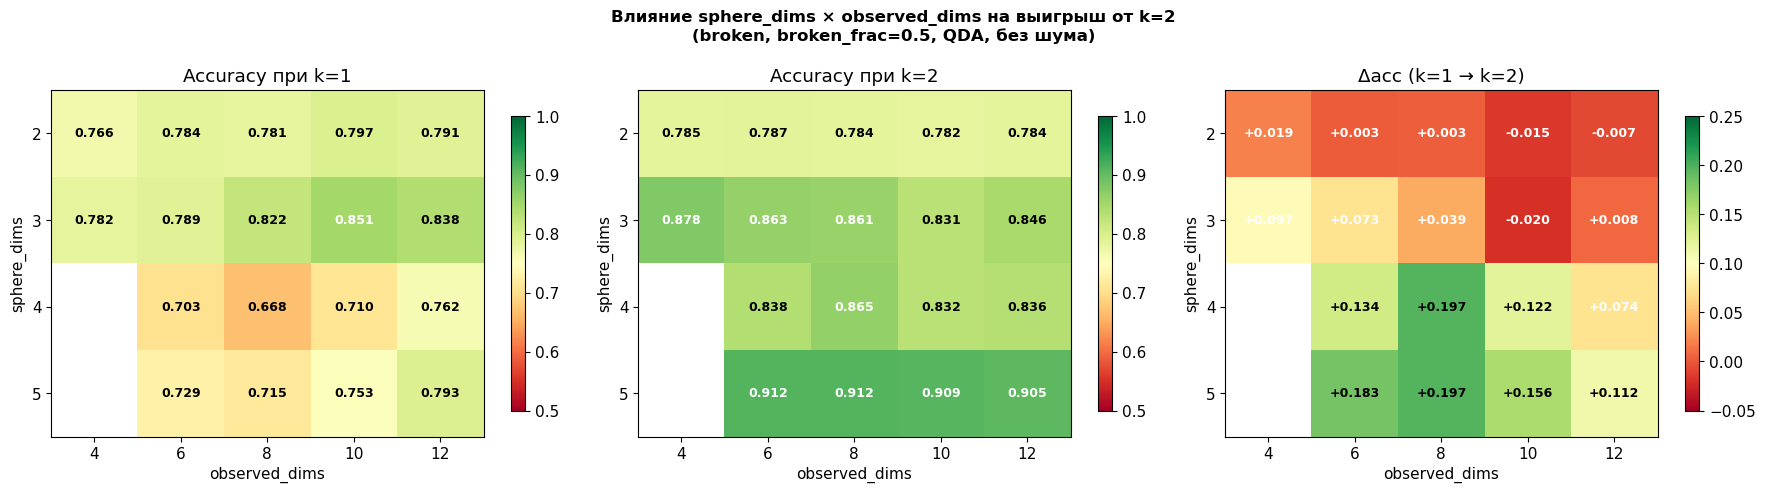

Сохранён: images/k_improvement_heatmap_dims.png


In [115]:
# ─── Тепловая карта Δacc ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

titles = [
    ("Accuracy при k=1", lambda sd, od: heatmap_data.get((sd,od), {}).get(1, {}).get("acc_mean", np.nan)),
    ("Accuracy при k=2", lambda sd, od: heatmap_data.get((sd,od), {}).get(2, {}).get("acc_mean", np.nan)),
    ("Δacc (k=1 → k=2)", lambda sd, od: (
        heatmap_data.get((sd,od), {}).get(2, {}).get("acc_mean", np.nan) -
        heatmap_data.get((sd,od), {}).get(1, {}).get("acc_mean", np.nan)
    )),
]

for ax, (title, fn) in zip(axes, titles):
    matrix = np.full((len(sphere_dims_range), len(observed_dims_range)), np.nan)
    for i, sd in enumerate(sphere_dims_range):
        for j, od in enumerate(observed_dims_range):
            if sd < od:
                matrix[i, j] = fn(sd, od)

    if "Δ" in title:
        cmap, vmin, vmax = "RdYlGn", -0.05, 0.25
    else:
        cmap, vmin, vmax = "RdYlGn", 0.5, 1.0

    im = ax.imshow(matrix, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_xticks(range(len(observed_dims_range)))
    ax.set_xticklabels(observed_dims_range)
    ax.set_yticks(range(len(sphere_dims_range)))
    ax.set_yticklabels(sphere_dims_range)
    ax.set_xlabel("observed_dims")
    ax.set_ylabel("sphere_dims")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.85)

    for i in range(len(sphere_dims_range)):
        for j in range(len(observed_dims_range)):
            val = matrix[i, j]
            if not np.isnan(val):
                color = "black" if 0.1 < val < 0.85 else "white"
                fmt = f"{val:+.3f}" if "Δ" in title else f"{val:.3f}"
                ax.text(j, i, fmt, ha="center", va="center",
                        fontsize=9, color=color, fontweight="bold")

plt.suptitle(
    "Влияние sphere_dims × observed_dims на выигрыш от k=2\n"
    "(broken, broken_frac=0.5, QDA, без шума)",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig("images/k_improvement_heatmap_dims.png", dpi=120, bbox_inches="tight")
plt.show()
print("Сохранён: images/k_improvement_heatmap_dims.png")

### 9.1.3 Выводы

**Когда k>1 значимо помогает:**

1. **Случайное вращение + малая размерность сферы** — ключевой фактор. Когда сфера в 4–5D вращается в 6–8D пространство, отдельные координаты теряют информацию о радиусе, но пары координат её сохраняют. Поэтому k=2 (парные классификаторы) значимо лучше k=1.

2. **broken_fraction=0.5** — оптимальна. При 0.3 слишком много информативных координат (k=1 хватает), при 0.7 — слишком мало полезного сигнала даже для пар.

3. **Чёткий зазор радиусов** `r_ctrl=(0.01, 0.4), r_case=(0.6, 1.0)` — даёт наибольший Δacc, так как задача принципиально решаемая, но требует учёта взаимодействий.

4. **Пик при k=2** — в большинстве конфигураций k=2 лучше k=3. Это объясняется тем, что при k=3 число подмножеств $\binom{d}{3}$ велико, а каждый тройной классификатор видит больше шумовых измерений, что ухудшает агрегацию.

**Почему QDA как внутренний классификатор:**
- QDA умеет строить квадратичные границы решений, что необходимо для распознавания сферической структуры
- При k=1 (1D данные) QDA вырождается в порог по дисперсии — слишком грубо
- При k=2 (2D данные) QDA может найти эллиптическую границу, восстанавливая часть сферической структуры


## 8. Заключение

В этом ноутбуке исследована модель **MyModelSynolitic** — k-порядковое приближение условной плотности $p(y|\mathbf{x})$ через формулу обращения Мёбиуса:

$$
\log p(y|\mathbf{x}) \approx_k \sum_{t=0}^{k} c^{(k)}(t, d) \cdot \sum_{T \subset [d]; |T|=t} \log p(y|x_T) + A_{d,k} \cdot \log p(y)
$$

### Основные результаты

1. **Демонстрация модели** (Секция 2): Коэффициенты Мёбиуса соответствуют теоретическим значениям. k=1 — Naive Bayes, k=2 — синолитика.

2. **Прямое предсказание vs признаки** (Секция 3): Синолитическая модель может работать как самостоятельный классификатор (`.predict(X)`) или как экстрактор признаков для внешних методов.

3. **Влияние k** (Секция 4): Переход k=0→1 даёт наибольший прирост качества; k=2 добавляет меньше, но стабильно.

4. **Влияние d** (Секция 5): С ростом размерности качество снижается; k=2 становится заметно лучше k=0 при малых d, но при большом d может переобучиться.

5. **Влияние шума** (Секция 6): Синолитика (k=2) устойчивее к умеренному шуму за счёт учёта взаимодействий.

6. **Влияние размера выборки** (Секция 7): k=1 требует меньше данных для стабилизации; k=2 раскрывает потенциал при достаточном объёме.

### Сравнение с оригинальным MyModel

| Свойство | MyModel (оценщик плотности) | MyModelSynolitic (классификатор) |
|---|---|---|
| Обучение | `fit(X)` — без меток | `fit(X, y)` — с метками |
| Цель | $p(\mathbf{x})$ | $p(y|\mathbf{x})$ |
| Предсказание | log-вероятность данных | метка класса / вероятности |
| Признаки | $s(i,t) = \sum \log p(x_T)$ | $s(i,t) = \sum \log p(y|x_T)$ |
